## This algorithm trains a model using influenza epitopes, with positive samples obtained from the Immune Epitope Database (IEDB) (https://www.iedb.org/), while negative epitopes were generated using a script as peptides of lengths 12, 14, and 16. 


     NumTiny  NumSmall  NumAliphatic  NumAromatic  NumNonPolar  NumPolar  \
0          6         8             1            2            6         5   
1          2         2             5            0            7         4   
2          3         6             3            2            6         5   
3          1         2             2            2            3        10   
4          3         7             3            4            7         7   
..       ...       ...           ...          ...          ...       ...   
711        7        12             4            2            9         7   
712        6        12             3            3            9         7   
713        7        14             3            2            9         7   
714        5        12             3            2            8         8   
715        5        10             4            3           10         6   

     NumCharged  NumBasic  NumAcidic  PorcTiny  ...        z3        z4  \
0           

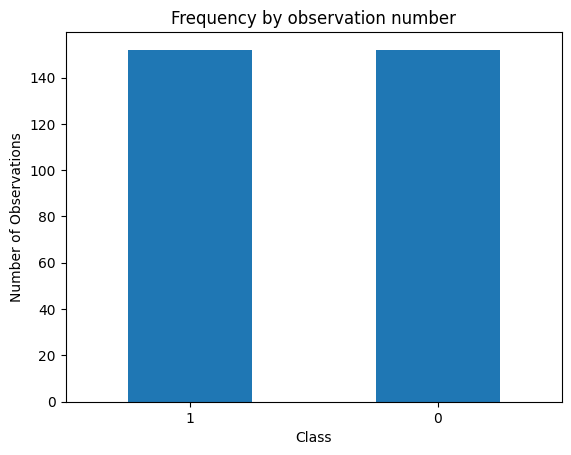

In [2]:
#MODULOS NECESARIOS

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.metrics import f1_score
from sklearn.metrics import matthews_corrcoef
from joblib import dump, load
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif
import warnings
warnings.filterwarnings("ignore")
cdhit = '85'

#ALGORITMO CLASIFICADOR
classifiers = [RandomForestClassifier(random_state=123),
               GaussianNB(var_smoothing=1e-9),
               DecisionTreeClassifier(random_state=123,min_samples_split=100),
               xgb.XGBClassifier(n_estimators=2, max_depth=2, learning_rate=1, objective='binary:logistic'),
               SVC(random_state=123, probability=True)]  
result_table = pd.DataFrame(columns=['classifiers','fpr','tpr','auc'])

graph_acc=[]
Acc = [];Rec = [];Pre = [];acc = [];rec = [];pre = [];acc_std = [];rec_std = [];pre_std = [];F1 = [];Matt = [];f1 = []; matt=[];f1_std = []; matt_std = []
Std = [];Mean = [];Fpr = [];Tpr = [];Auc = [];Auc2 = [];Auc3 = []
mean_tpr=[]; W_range = range(0, 100)
feature_cols =['PorcTiny','PorcSmall','PorcAliphatic','PorcAromatic','PorcNonPolar','PorcPolar','PorcCharged','PorcBasic','PorcAcidic','at_index','at_boman','at_charge','at_pi','at_hmoment_alpha','at_hmoment_sheet','HelixBendPreference','SideChainSize','ExtendedStructurePreference','Hidrophobicity','DoubleBendPreference','PartialSpecificVolume','FlatExtendedPreference','OccurrenceInAlphaRegion','pKC','SurroundingHidrophobicity','Blosum1','Blosum2','Blosum3','Blosum4','Blosum5','Blosum6','Blosum7','Blosum8','Blosum9','Blosum10','MsWhim1','MsWhim2','MsWhim3','st1','st2','st3','st4','st5','st6','st7','st8','t1','t2','t3','t4','t5','z1','z2','z3','z4','z5','HydrophobicityIndex','AlphaAndTurnPropensities','BulkyProperties','CompositionalCharacteristicIndex','LocalFlexibility','ElectronicProperties']

cols=[*range(1, 75, 1)]
df_ref = pd.read_csv(f'{cdhit}-16-descriptors_class_Algorithm.csv', sep=',',usecols=cols)
print(df_ref)
X=df_ref[feature_cols]
Y=df_ref.Class
X_p=preprocessing.normalize(X)
df2=df_ref.iloc[np.random.random_integers(152,715,152),0:74]
    #148,609,148),0:74]
#df2=df_ref.iloc[np.random.random_integers(256,2050,257),0:74]
#size for positive and negative samples is 257
df2.to_csv(f'{cdhit}-16-source_nonEpAl.csv', index=True)
df3=df_ref.iloc[0:152,0:74]
frames = [df3, df2]
df4=pd.concat(frames)
Xrandom=df4[feature_cols]
print(Xrandom)
Yrandom=df4.Class
print(Yrandom)
X_prandom=preprocessing.normalize(Xrandom)
count_classes = Yrandom.value_counts()
count_classes.plot(kind = 'bar', rot=0)
plt.xticks(range(2))
plt.title("Frequency by observation number")
plt.xlabel("Class")
plt.ylabel("Number of Observations");

RF,GaussianNB,DT,XG,SVM
acc
[0.6588524590163936, 0.6336065573770492, 0.5970491803278689, 0.5949180327868853, 0.5198360655737706] [0.05161696106102095, 0.046215263472165403, 0.058659210556135745, 0.061701006827141275, 0.05684980234683755]
rec
[0.6134482758620688, 0.7068965517241379, 0.543448275862069, 0.6248275862068965, 0.5658620689655172] [0.06709444600634937, 0.06623921624930533, 0.17778662945330348, 0.12996661054791236, 0.1575748882979662]
pre
[0.6532103434342086, 0.5994344604608046, 0.5965723137389471, 0.5724565386711569, 0.494491778336831] [0.06621706403529938, 0.0484568251573441, 0.08455187373833531, 0.06574624746485964, 0.06022705370852717]
f1
[0.6305695352439669, 0.6468434571456473, 0.5490543412966986, 0.5901233460308779, 0.5197339092808629] [0.05516637413647363, 0.04371302089998709, 0.09946415438371213, 0.07290847461548573, 0.08904085153529534]
matt
[0.3167479171645414, 0.27783106219683984, 0.20257347190712569, 0.19809464053094283, 0.04686465265556859] [0.1042955569782133, 0.0

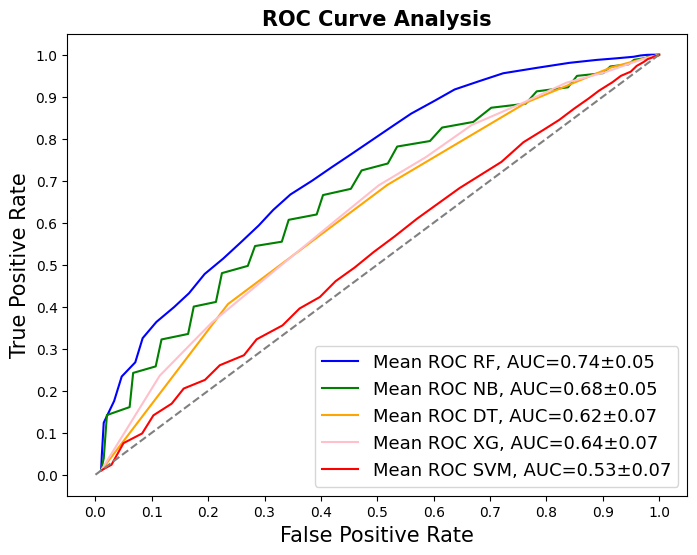

In [3]:
count = 0
for cls in classifiers: #BUCLE PARA CADA ALGORITMO CLASIFICADOR, RANDOM FOREST
    count=count+1
    if count == 1:
        name = "RF"
    if count == 2:
        name = "NB"
    if count == 3:
        name = "DT"
    if count == 4:
        name = "SVM"
    if count ==5:
        name = "XG"
    for i in W_range:   #BUCLE DE 100 REPETICIONES
        fpr_all=[]      #SETEAR VARIABLES, LISTAS VACÍAS PARA MATRIZ DE COSTO
        tpr_all=[]
        df2=df_ref.iloc[np.random.random_integers(152,715,152),0:74]  #SELECCION DE EJEMPLOS NEGATIVOS
        df2.to_csv(f'{cdhit}-16-source_nonEpiRef_'+str(name)+'_'+str(i)+'.csv', index=True)
        df3=df_ref.iloc[0:152,0:74] #EJEMPLOS POSITIVOS
        frames = [df3, df2]
        df4=pd.concat(frames)
        X_r=df4[feature_cols]    #SELECCION DE LOS DESCRIPTORES ELEGIDOS
        Y_r=df4.Class
        Y_r.value_counts()
        X_rn=preprocessing.normalize(X_r)          #ESCALAR VALORES DE DESCRIPTORS
        X_train, X_test, y_train, y_test = train_test_split(X_rn,Y_r, test_size=0.20,random_state=123) #DIVIDIR SET DE DATOS EN ENTRENAMIENTO Y PRUEBA
        model = cls.fit(X_train, y_train)          #CONSTRUIR MODELO
        y_pred = model.predict_proba(X_test)[::,1] #PREDECIR VALORES PARA EL TEST
        fpr, tpr, _ = roc_curve(y_test,y_pred)     #IDENTIFICAR FALSOS Y VERDADEROS POSITIVOS PARA CONTRUIR CURVA ROC
        fpr_all.append(fpr)
        tpr_all.append(tpr)
        auc = roc_auc_score(y_test, y_pred)        #CALCULAR VALORES PARA CURVA ROC
        Auc.append(auc)
        Acc.append(metrics.accuracy_score(y_test, y_pred.round())) #CALCULAR ESTADICTICAS ACCURACY, RECALL Y PRECISION
        Rec.append(metrics.recall_score(y_test,y_pred.round(),average='binary',pos_label = 1))
        Pre.append(metrics.precision_score(y_test,y_pred.round(),average='binary',pos_label = 1))
        F1.append(metrics.f1_score(y_test,y_pred.round(),average='binary',pos_label = 1))
        Matt.append(metrics.matthews_corrcoef(y_test,y_pred.round()))
        result_table = result_table._append({'classifiers':cls.__class__.__name__,
                                        'fpr':fpr,
                                        'tpr':tpr,
                                        'auc':auc}, ignore_index=True)

    Auc2.append(np.mean(Auc))
    Auc3.append(np.std(Auc))
    acc.append(np.mean(Acc)) #RESCATAR VALORES PARA CADA CLASIFICADOR
    rec.append(np.mean(Rec))
    pre.append(np.mean(Pre))
    f1.append(np.mean(F1))
    matt.append(np.mean(Matt))
    acc_std.append(np.std(Acc))
    rec_std.append(np.std(Rec))
    pre_std.append(np.std(Pre))
    f1_std.append(np.std(F1))
    matt_std.append(np.std(Matt))
    Auc=[] #VACIAR LISTAS
    Acc=[]
    Rec=[]
    Pre=[]
    F1=[]
    Matt=[]

##IMPRESION DE ESTADISTICAS ACCURACY, RECALL Y PRECISION JUNTO A SUS DESVIACIONES
##RF,GaussianNB,DT,XGB,SVC
print("RF,GaussianNB,DT,XG,SVM")
print("acc")
print(acc,acc_std)
print("rec")
print(rec,rec_std)
print("pre")
print(pre,pre_std)
print("f1")
print(f1,f1_std)
print("matt")
print(matt,matt_std)

fpr_rf=result_table['fpr'][0:99]
fpr_nb=result_table['fpr'][100:199]
fpr_dt=result_table['fpr'][200:299]
fpr_xg=result_table['fpr'][300:399]
fpr_svm=result_table['fpr'][400:499]

tpr_rf=result_table['tpr'][0:99]
tpr_nb=result_table['tpr'][100:199]
tpr_dt=result_table['tpr'][200:299]
tpr_xg=result_table['tpr'][300:399]
tpr_svm=result_table['tpr'][400:499]

fpr_rf =fpr_rf.to_list()
fpr_nb =fpr_nb.to_list()
fpr_dt =fpr_dt.to_list()
fpr_xg =fpr_xg.to_list()
fpr_svm =fpr_svm.to_list()

tpr_rf =tpr_rf.to_list()
tpr_nb =tpr_nb.to_list()
tpr_dt =tpr_dt.to_list()
tpr_xg =tpr_xg.to_list()
tpr_svm=tpr_svm.to_list()

matrix=np.zeros((2000,100))
for i in np.arange(0,2000,1):
    for j in np.arange(0,100,1):
        matrix[i][j]=1
        j=j+1
    i=i+1    
fila=0
for elemento in fpr_rf:            # lista de largo 100 y de 83 valores c/u, hay que sumar las 100 filas de 83 cols 
    col=0
    for elemento2 in elemento:    # 84
        if col < 2000: #columnas
            matrix[col][fila]=elemento2
        col=col+1     # hasta el 83 #   nuevalista.append(elemento2) #  print(nuevalista)
    fila=fila+1 
mean_fpr_rf = np.mean(matrix,axis=1)
std_fpr_rf = np.std(matrix,axis=1)
for i in np.arange(0,2000,1):
    for j in np.arange(0,100,1):
        matrix[i][j]=1
        j=j+1
    i=i+1    
fila=0
for elemento in tpr_rf:            # lista de largo 100 y de 83 valores c/u, hay que sumar las 100 filas de 83 cols 
    col=0
    for elemento2 in elemento:    # 84
        if col < 2000: #columnas
            matrix[col][fila]=elemento2
        col=col+1     # hasta el 83 #   nuevalista.append(elemento2) #  print(nuevalista)
    fila=fila+1 
mean_tpr_rf = np.mean(matrix,axis=1)
std_tpr_rf = np.std(matrix,axis=1)


for i in np.arange(0,2000,1):
    for j in np.arange(0,100,1):
        matrix[i][j]=1
        j=j+1
    i=i+1    
fila=0
for elemento in fpr_dt:            # lista de largo 100 y de 83 valores c/u, hay que sumar las 100 filas de 83 cols 
    col=0
    for elemento2 in elemento:    # 84
        if col < 2000: #columnas
            matrix[col][fila]=elemento2
        col=col+1     # hasta el 83 #   nuevalista.append(elemento2) #  print(nuevalista)
    fila=fila+1 
mean_fpr_dt = np.mean(matrix,axis=1)
std_fpr_dt = np.std(matrix,axis=1)

for i in np.arange(0,2000,1):
    for j in np.arange(0,100,1):
        matrix[i][j]=1
        j=j+1
    i=i+1    
fila=0
for elemento in tpr_dt:            # lista de largo 100 y de 83 valores c/u, hay que sumar las 100 filas de 83 cols 
    col=0
    for elemento2 in elemento:    # 84
        if col < 2000: #columnas
            matrix[col][fila]=elemento2
        col=col+1     # hasta el 83 #   nuevalista.append(elemento2) #  print(nuevalista)
    fila=fila+1 
mean_tpr_dt = np.mean(matrix,axis=1)
std_tpr_dt = np.std(matrix,axis=1)

matrix=np.zeros((2000,100))
for i in np.arange(0,2000,1):
    for j in np.arange(0,100,1):
        matrix[i][j]=1
        j=j+1
    i=i+1    
fila=0
for elemento in fpr_svm:            # lista de largo 100 y de 83 valores c/u, hay que sumar las 100 filas de 83 cols 
    col=0
    for elemento2 in elemento:    # 84
        if col < 2000: #columnas
            matrix[col][fila]=elemento2
        col=col+1     # hasta el 83 #   nuevalista.append(elemento2) #  print(nuevalista)
    fila=fila+1 
mean_fpr_svm = np.mean(matrix,axis=1)
std_fpr_svm = np.std(matrix,axis=1)

for i in np.arange(0,2000,1):
    for j in np.arange(0,100,1):
        matrix[i][j]=1
        j=j+1
    i=i+1    
fila=0
for elemento in tpr_svm:            # lista de largo 100 y de 83 valores c/u, hay que sumar las 100 filas de 83 cols 
    col=0
    for elemento2 in elemento:    # 84
        if col < 2000: #columnas
            matrix[col][fila]=elemento2
        col=col+1     # hasta el 83 #   nuevalista.append(elemento2) #  print(nuevalista)
    fila=fila+1 
mean_tpr_svm = np.mean(matrix,axis=1)
std_tpr_svm = np.std(matrix,axis=1)


for i in np.arange(0,2000,1):
    for j in np.arange(0,100,1):
        matrix[i][j]=1
        j=j+1
    i=i+1    
fila=0
for elemento in fpr_nb:            # lista de largo 100 y de 83 valores c/u, hay que sumar las 100 filas de 83 cols 
    col=0
    for elemento2 in elemento:    # 84
        if col < 2000: #columnas
            matrix[col][fila]=elemento2
        col=col+1     # hasta el 83 #   nuevalista.append(elemento2) #  print(nuevalista)
    fila=fila+1 
mean_fpr_nb = np.mean(matrix,axis=1)
std_fpr_nb = np.std(matrix,axis=1)

for i in np.arange(0,2000,1):
    for j in np.arange(0,100,1):
        matrix[i][j]=1
        j=j+1
    i=i+1    
fila=0
for elemento in tpr_nb:            
    col=0
    for elemento2 in elemento:    
        if col < 2000: #columnas
            matrix[col][fila]=elemento2
        col=col+1    
    fila=fila+1 
mean_tpr_nb = np.mean(matrix,axis=1)
std_tpr_nb = np.std(matrix,axis=1)
##xg
for i in np.arange(0,2000,1):
    for j in np.arange(0,100,1):
        matrix[i][j]=1
        j=j+1
    i=i+1    
fila=0
for elemento in fpr_xg:            # lista de largo 100 y de 83 valores c/u, hay que sumar las 100 filas de 83 cols 
    col=0
    for elemento2 in elemento:    # 84
        if col < 2000: #columnas
            matrix[col][fila]=elemento2
        col=col+1     # hasta el 83 #   nuevalista.append(elemento2) #  print(nuevalista)
    fila=fila+1 
mean_fpr_xg = np.mean(matrix,axis=1)
std_fpr_xg = np.std(matrix,axis=1)

for i in np.arange(0,2000,1):
    for j in np.arange(0,100,1):
        matrix[i][j]=1
        j=j+1
    i=i+1    
fila=0
for elemento in tpr_xg:            # lista de largo 100 y de 83 valores c/u, hay que sumar las 100 filas de 83 cols 
    col=0
    for elemento2 in elemento:    # 84
        if col < 2000: #columnas
            matrix[col][fila]=elemento2
        col=col+1     # hasta el 83 #   nuevalista.append(elemento2) #  print(nuevalista)
    fila=fila+1
mean_tpr_xg = np.mean(matrix,axis=1)
std_tpr_xg = np.std(matrix,axis=1)


plt.figure(figsize=(8,6))
clasif = ["RF","NB","DT","XG","SVM"]
plt.plot(mean_fpr_rf, mean_tpr_rf, color='blue', label="Mean ROC {}, AUC={:.2f}±{:.2f}".format(clasif[0], Auc2[0],Auc3[0]))
plt.plot(mean_fpr_nb, mean_tpr_nb, color='green', label="Mean ROC {}, AUC={:.2f}±{:.2f}".format(clasif[1], Auc2[1],Auc3[1]))
plt.plot(mean_fpr_dt, mean_tpr_dt, color='orange',label="Mean ROC {}, AUC={:.2f}±{:.2f}".format(clasif[2], Auc2[2],Auc3[2]))
plt.plot(mean_fpr_xg,mean_tpr_xg,color='pink',  label="Mean ROC {}, AUC={:.2f}±{:.2f}".format(clasif[3], Auc2[3],Auc3[3]))
plt.plot(mean_fpr_svm, mean_tpr_svm, color='red',   label="Mean ROC {}, AUC={:.2f}±{:.2f}".format(clasif[4], Auc2[4],Auc3[4]))
plt.plot([0,1], [0,1], color='grey', linestyle='--')
plt.xticks(np.arange(0.0, 1.1, step=0.1))
plt.xlabel("False Positive Rate", fontsize=15)
plt.yticks(np.arange(0.0, 1.1, step=0.1))
plt.ylabel("True Positive Rate", fontsize=15)
plt.title('ROC Curve Analysis', fontweight='bold', fontsize=15)
plt.legend(prop={'size':13}, loc='lower right')
result_table.set_index('classifiers', inplace=True)
plt.savefig(f'{cdhit}-16-ROCcurve_0.png')
plt.show()


#dump(cls, 'model.joblib') 

152 152


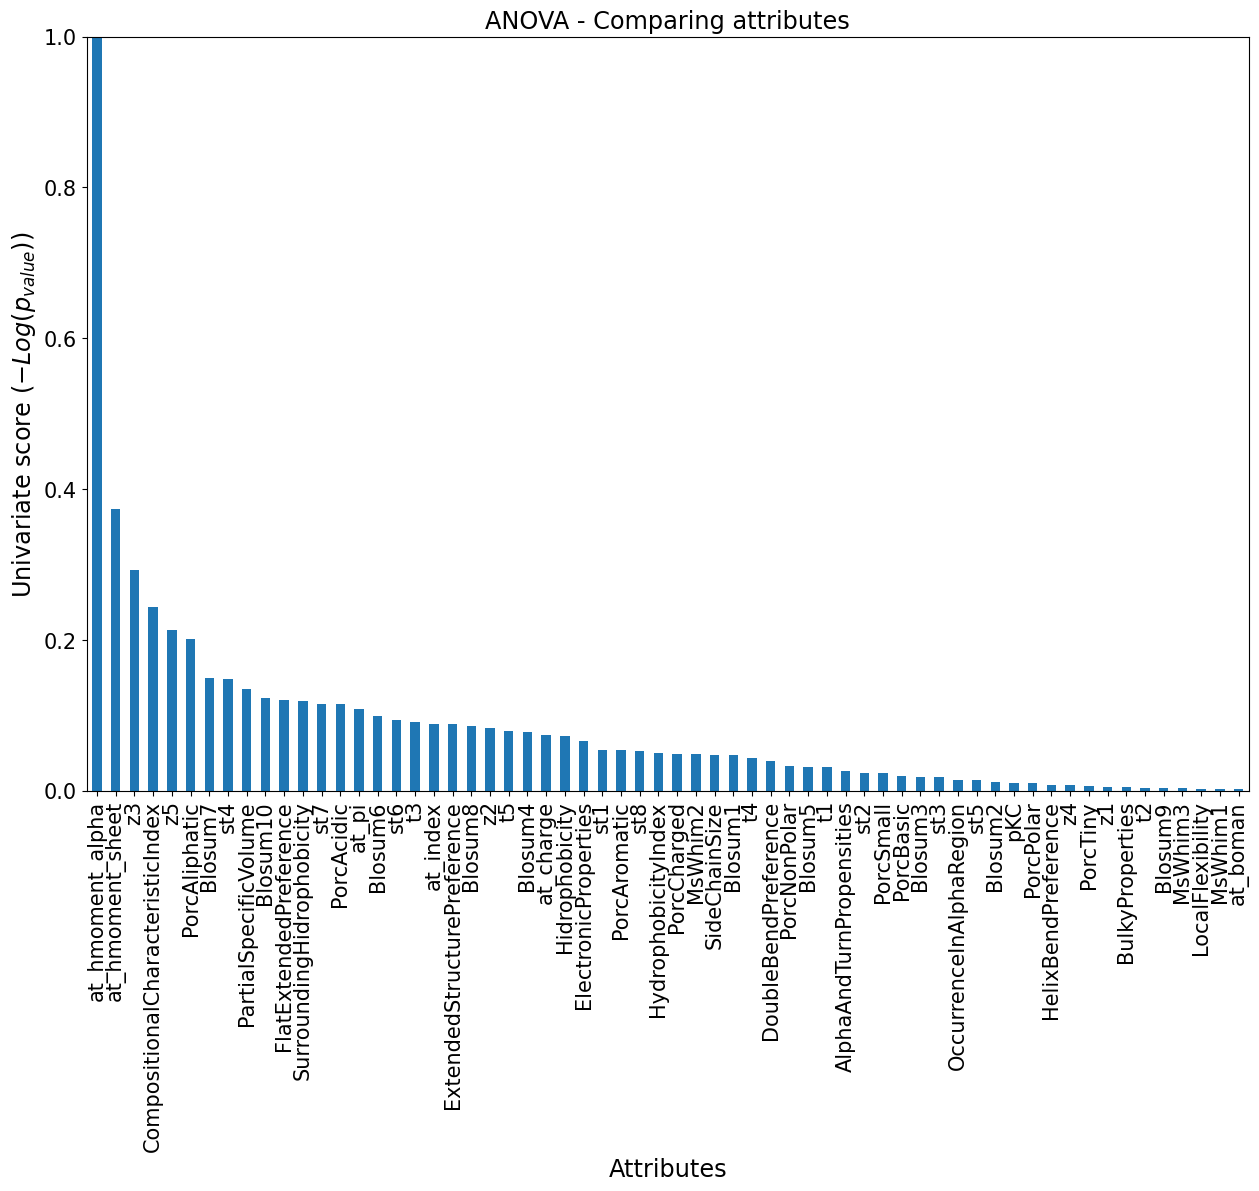

In [4]:
#select ANOVA
feature_cols =['PorcTiny','PorcSmall','PorcAliphatic','PorcAromatic','PorcNonPolar','PorcPolar','PorcCharged','PorcBasic','PorcAcidic','at_index','at_boman','at_charge','at_pi','at_hmoment_alpha','at_hmoment_sheet','HelixBendPreference','SideChainSize','ExtendedStructurePreference','Hidrophobicity','DoubleBendPreference','PartialSpecificVolume','FlatExtendedPreference','OccurrenceInAlphaRegion','pKC','SurroundingHidrophobicity','Blosum1','Blosum2','Blosum3','Blosum4','Blosum5','Blosum6','Blosum7','Blosum8','Blosum9','Blosum10','MsWhim1','MsWhim2','MsWhim3','st1','st2','st3','st4','st5','st6','st7','st8','t1','t2','t3','t4','t5','z1','z2','z3','z4','z5','HydrophobicityIndex','AlphaAndTurnPropensities','BulkyProperties','CompositionalCharacteristicIndex','LocalFlexibility','ElectronicProperties']
X=df_ref[feature_cols]
Y=df_ref.Class

df2=df_ref.iloc[np.random.random_integers(152,715,152),0:74]
df3=df_ref.iloc[0:152,0:74]
print(len(df2),len(df3))

frames = [df3, df2]
df4=pd.concat(frames)
Xrandom=df4[feature_cols]
Y=df4.Class

X_p=preprocessing.normalize(Xrandom)
df2.to_csv(f'{cdhit}-16-source_nonEpiAl_ANOVA.csv', index=True)
asel = SelectKBest(f_classif, k='all')

asel.fit(X_p,Y)
scores = asel.scores_[asel.get_support()]
total_f_reg=-np.log10(asel.pvalues_)
total_f_reg /= total_f_reg.max()
names_scores = zip(feature_cols, total_f_reg)
ns_df = pd.DataFrame(data = names_scores, columns=['Feat_names', 'F_reg_Scores'])
ns_df_sorted = ns_df.sort_values(['F_reg_Scores', 'Feat_names'], ascending = [False, True])
X_indices = np.arange(X.shape[-1])
plt.figure(figsize=(15, 13))
plt.xticks(X_indices,ns_df_sorted['Feat_names'],rotation=90,fontsize='15')
plt.yticks(fontsize='15')
plt.bar(X_indices, ns_df_sorted['F_reg_Scores'], label="Regression($-Log(p_{value})$)",width=0.5)
plt.title("ANOVA - Comparing attributes",fontsize='xx-large')
plt.xlabel("Attributes",fontsize='xx-large')
plt.ylabel("Univariate score ($-Log(p_{value})$)",fontsize='xx-large')

plt.subplots_adjust(bottom=0.3)
plt.margins(0.005)
plt.ylim(0, 1)
plt.savefig(f'{cdhit}-16-ANOVA_NegEpiPaper.png')#,pad_inches=1.5)
plt.show()

In [5]:
print(list(ns_df_sorted['Feat_names']))
print(*ns_df_sorted['Feat_names'][0:20])
print(list(ns_df_sorted['F_reg_Scores']))

['at_hmoment_alpha', 'at_hmoment_sheet', 'z3', 'CompositionalCharacteristicIndex', 'z5', 'PorcAliphatic', 'Blosum7', 'st4', 'PartialSpecificVolume', 'Blosum10', 'FlatExtendedPreference', 'SurroundingHidrophobicity', 'st7', 'PorcAcidic', 'at_pi', 'Blosum6', 'st6', 't3', 'at_index', 'ExtendedStructurePreference', 'Blosum8', 'z2', 't5', 'Blosum4', 'at_charge', 'Hidrophobicity', 'ElectronicProperties', 'st1', 'PorcAromatic', 'st8', 'HydrophobicityIndex', 'PorcCharged', 'MsWhim2', 'SideChainSize', 'Blosum1', 't4', 'DoubleBendPreference', 'PorcNonPolar', 'Blosum5', 't1', 'AlphaAndTurnPropensities', 'st2', 'PorcSmall', 'PorcBasic', 'Blosum3', 'st3', 'OccurrenceInAlphaRegion', 'st5', 'Blosum2', 'pKC', 'PorcPolar', 'HelixBendPreference', 'z4', 'PorcTiny', 'z1', 'BulkyProperties', 't2', 'Blosum9', 'MsWhim3', 'LocalFlexibility', 'MsWhim1', 'at_boman']
at_hmoment_alpha at_hmoment_sheet z3 CompositionalCharacteristicIndex z5 PorcAliphatic Blosum7 st4 PartialSpecificVolume Blosum10 FlatExtendedPrefe

In [6]:
feature_coll = list(ns_df_sorted['Feat_names'])#['PorcAliphatic', 'z1', 'OccurrenceInAlphaRegion', 'SurroundingHidrophobicity', 't4', 'PartialSpecificVolume', 'PorcAcidic', 'pKC', 'PorcAromatic', 'Blosum1', 'st6', 'Blosum6', 'z5', 'at_charge', 'st5', 'Blosum2', 'st3', 'PorcBasic', 'MsWhim1', 'PorcSmall', 'Blosum7', 'FlatExtendedPreference', 'at_hmoment_sheet', 'st1', 'PorcNonPolar', 'at_boman', 't1', 'Blosum5', 'st2', 'LocalFlexibility', 'at_index', 'ElectronicProperties', 'Blosum10', 'at_pi', 'ExtendedStructurePreference', 'Blosum3', 'Hidrophobicity', 'z2', 'st7', 'PorcPolar', 'CompositionalCharacteristicIndex', 'MsWhim2', 'Blosum8', 'HelixBendPreference', 'st4', 'at_hmoment_alpha', 'MsWhim3', 'PorcTiny', 'st8', 'Blosum9', 'AlphaAndTurnPropensities', 't3', 'BulkyProperties']#list(ns_df_sorted['Feat_names'])
                                               #at_hmoment_sheet at_hmoment_alpha PorcBasic Blosum9 PorcCharged at_pi st7 z3 SideChainSize t2 at_boman st8 ElectronicProperties st2 Blosum2 PorcPolar z5 ExtendedStructurePreference SurroundingHidrophobicity BulkyProperties
print(feature_coll[0])
graph_acc=[]
V_range = range(0, 62) #
print(V_range) #62 1,63*
Acc = []
Rec = []
Pre = []
Std = []
Mean = []
fc = []
W_range = range(0, 100)
for k in V_range: #atributos
    fc.append(feature_coll[k])
    #print(feature_coll[fc].head(0))
    print(fc)
    for l in W_range: #100 veces
        df2=df_ref.iloc[np.random.random_integers(152,715,152),0:74]
        df3=df_ref.iloc[0:152,0:74] 
        frames = [df3, df2]
        df4=pd.concat(frames)
        X_r=df4[fc]
        Y_r=df4.Class
        X_rn=preprocessing.normalize(X_r)
        X_train, X_test, y_train, y_test = train_test_split(X_rn,Y_r, test_size=0.2,random_state=123)
        RF = RandomForestClassifier(random_state=123)#,n_estimators=1000)
        RF.fit(X_train, y_train)
        y_pred = RF.predict(X_test)
        Acc.append(metrics.accuracy_score(y_test, y_pred))
        Rec.append(metrics.recall_score(y_test,y_pred,average='binary',pos_label = 1))
        Pre.append(metrics.precision_score(y_test,y_pred,average='binary',pos_label = 1))
    Mean.append(np.mean(Acc))
    Std.append(np.std(Acc))

at_hmoment_alpha
range(0, 62)
['at_hmoment_alpha']
['at_hmoment_alpha', 'at_hmoment_sheet']
['at_hmoment_alpha', 'at_hmoment_sheet', 'z3']
['at_hmoment_alpha', 'at_hmoment_sheet', 'z3', 'CompositionalCharacteristicIndex']
['at_hmoment_alpha', 'at_hmoment_sheet', 'z3', 'CompositionalCharacteristicIndex', 'z5']
['at_hmoment_alpha', 'at_hmoment_sheet', 'z3', 'CompositionalCharacteristicIndex', 'z5', 'PorcAliphatic']
['at_hmoment_alpha', 'at_hmoment_sheet', 'z3', 'CompositionalCharacteristicIndex', 'z5', 'PorcAliphatic', 'Blosum7']
['at_hmoment_alpha', 'at_hmoment_sheet', 'z3', 'CompositionalCharacteristicIndex', 'z5', 'PorcAliphatic', 'Blosum7', 'st4']
['at_hmoment_alpha', 'at_hmoment_sheet', 'z3', 'CompositionalCharacteristicIndex', 'z5', 'PorcAliphatic', 'Blosum7', 'st4', 'PartialSpecificVolume']
['at_hmoment_alpha', 'at_hmoment_sheet', 'z3', 'CompositionalCharacteristicIndex', 'z5', 'PorcAliphatic', 'Blosum7', 'st4', 'PartialSpecificVolume', 'Blosum10']
['at_hmoment_alpha', 'at_hmoment

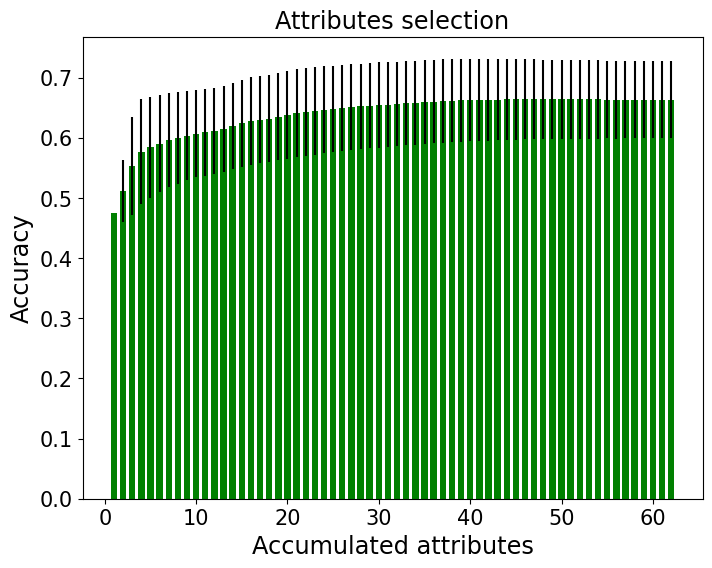

In [7]:
#plot
rango=[]
for i in V_range:
    rango.append(i+1)
import matplotlib.pyplot as plot
plt.figure(figsize=(8,6))
plt.bar(rango,Mean,yerr=Std,color="green",width=0.7)
plt.ylabel('Accuracy',fontsize='xx-large')
plt.xlabel('Accumulated attributes', fontsize='xx-large')
plt.xticks(fontsize='15')
plt.yticks(fontsize='15')
plt.title('Attributes selection',fontsize='xx-large')
plt.savefig(f'{cdhit}-16-AccurracyANOVA_NegEpipaper.png')
plt.show()

RF,GaussianNB,DT,XGB,SVC
acc
[0.6908196721311475, 0.5750819672131147, 0.6172131147540983, 0.5991803278688524, 0.48180327868852457] [0.0491267467684519, 0.05035109198807205, 0.06472296408606452, 0.06282667916703234, 0.05706684294132135]
rec
[0.6734482758620692, 0.8124137931034483, 0.5682758620689654, 0.6731034482758621, 0.2848275862068966] [0.06001486141751175, 0.09434926386020792, 0.12147331782788412, 0.12998490720034034, 0.28508796648154106]
pre
[0.6791061908127662, 0.5404834541198035, 0.6112611231816981, 0.5671039676001013, 0.35357917979482845] [0.06122599497731573, 0.05036113421675437, 0.08873772171416795, 0.06320930921832427, 0.161024534033614]
f1
[0.6743732352653866, 0.6436093582518346, 0.5810226520507219, 0.6102162321387159, 0.28273623569647244] [0.04904013457521204, 0.044177555210683665, 0.08268134659095389, 0.08072771858162277, 0.2010353351240959]
matt
[0.3821080255645108, 0.19339518439950246, 0.2363260653373979, 0.2113631210050607, -0.07401456328817935] [0.09791935210588647, 0

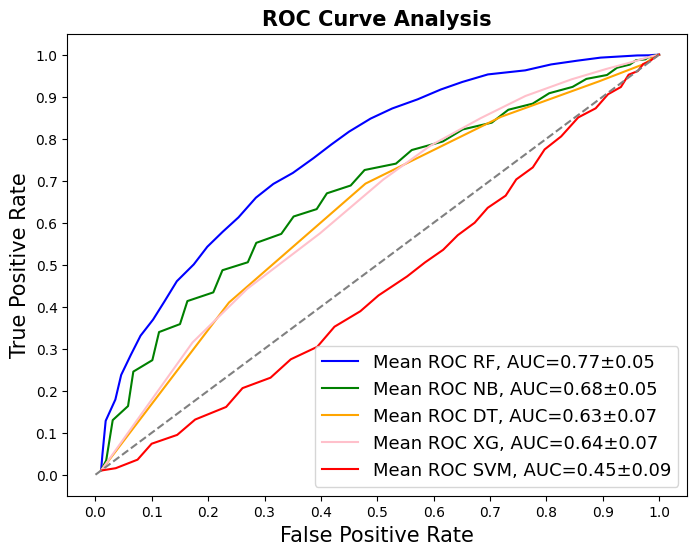

In [9]:
classifiers = [RandomForestClassifier(random_state=123),
               GaussianNB(var_smoothing=1e-9),#
               DecisionTreeClassifier(random_state=123,min_samples_split=100),
               xgb.XGBClassifier(n_estimators=2, max_depth=2, learning_rate=1, objective='binary:logistic'),
               SVC(random_state=123, probability=True)]  
##RF,GaussianNB,DT,XGB,SVC         

#TABLA RESULTADOS SOBRE MATRIZ DE CONFUSION Y CURVA ROC
result_table = pd.DataFrame(columns=['classifiers','fpr','tpr','auc'])

graph_acc=[]
Acc = [];Rec = [];Pre = [];acc = [];rec = [];pre = [];acc_std = [];rec_std = [];pre_std = [];F1 = [];Matt = [];f1 = []; matt=[];f1_std = []; matt_std = []
Std = [];Mean = [];Fpr = [];Tpr = [];Auc = [];Auc2 = [];Auc3 = []
mean_tpr=[]; W_range = range(0, 100)

#ANOVA selection of best 20
fc1=['at_hmoment_alpha', 'at_hmoment_sheet', 'z3', 'CompositionalCharacteristicIndex', 'z5', 'PorcAliphatic', 'Blosum7', 'st4', 'PartialSpecificVolume', 'Blosum10', 'FlatExtendedPreference', 'SurroundingHidrophobicity', 'st7', 'PorcAcidic', 'at_pi', 'Blosum6', 'st6', 't3', 'at_index', 'ExtendedStructurePreference']

count = 0
for cls in classifiers: #BUCLE PARA CADA ALGORITMO CLASIFICADOR, RANDOM FOREST
    count=count+1
    if count == 1:
        name = "RF"
    if count == 2:
        name = "NB"
    if count == 3:
        name = "DT"
    if count == 4:
        name = "SVM"
    if count ==5:
        name = "XG"
#print(cls)
    for i in W_range:   #BUCLE DE 100 REPETICIONES
        fpr_all=[]      #SETEAR VARIABLES, LISTAS VACÍAS PARA MATRIZ DE COSTO
        tpr_all=[]
        df2=df_ref.iloc[np.random.random_integers(152,715,152),0:74]  #SELECCION DE EJEMPLOS NEGATIVOS
        df2.to_csv(f'{cdhit}-16-source_nonEpiAl_'+str(name)+'_'+str(i)+'_ANOVA.csv', index=True)
        df3=df_ref.iloc[0:152,0:74] #EJEMPLOS POSITIVOS
        frames = [df3, df2]
        df4=pd.concat(frames)
        X_r=df4[fc1]    #SELECCION DE LOS DESCRIPTORES ELEGIDOS
        Y_r=df4.Class
        Y_r.value_counts()
        X_rn=preprocessing.normalize(X_r)          #ESCALAR VALORES DE DESCRIPTORS
        X_train, X_test, y_train, y_test = train_test_split(X_rn,Y_r, test_size=0.20,random_state=123) #DIVIDIR SET DE DATOS EN ENTRENAMIENTO Y PRUEBA
        model = cls.fit(X_train, y_train)          #CONSTRUIR MODELO
        y_pred = model.predict_proba(X_test)[::,1] #PREDECIR VALORES PARA EL TEST
        fpr, tpr, _ = roc_curve(y_test,y_pred)     #IDENTIFICAR FALSOS Y VERDADEROS POSITIVOS PARA CONTRUIR CURVA ROC
        fpr_all.append(fpr)
        tpr_all.append(tpr)
        auc = roc_auc_score(y_test, y_pred)        #CALCULAR VALORES PARA CURVA ROC
        Auc.append(auc)
        Acc.append(metrics.accuracy_score(y_test, y_pred.round())) #CALCULAR ESTADICTICAS ACCURACY, RECALL Y PRECISION
        Rec.append(metrics.recall_score(y_test,y_pred.round(),average='binary',pos_label = 1))
        Pre.append(metrics.precision_score(y_test,y_pred.round(),average='binary',pos_label = 1))
        F1.append(metrics.f1_score(y_test,y_pred.round(),average='binary',pos_label = 1))
        Matt.append(metrics.matthews_corrcoef(y_test,y_pred.round()))
        result_table = result_table._append({'classifiers':cls.__class__.__name__,
                                        'fpr':fpr,
                                        'tpr':tpr,
                                        'auc':auc}, ignore_index=True)

    Auc2.append(np.mean(Auc))
    Auc3.append(np.std(Auc))
    acc.append(np.mean(Acc)) #RESCATAR VALORES PARA CADA CLASIFICADOR
    rec.append(np.mean(Rec))
    pre.append(np.mean(Pre))
    f1.append(np.mean(F1))
    matt.append(np.mean(Matt))
    acc_std.append(np.std(Acc))
    rec_std.append(np.std(Rec))
    pre_std.append(np.std(Pre))
    f1_std.append(np.std(F1))
    matt_std.append(np.std(Matt))
    Auc=[] #VACIAR LISTAS
    Acc=[]
    Rec=[]
    Pre=[]
    F1=[]
    Matt=[]

##IMPRESION DE ESTADISTICAS ACCURACY, RECALL Y PRECISION JUNTO A SUS DESVIACIONES
print("RF,GaussianNB,DT,XGB,SVC")
#RF,GaussianNB,DT,XGB,SVC 
print("acc")
print(acc,acc_std)
print("rec")
print(rec,rec_std)
print("pre")
print(pre,pre_std)
print("f1")
print(f1,f1_std)
print("matt")
print(matt,matt_std)

fpr_rf=result_table['fpr'][0:99]
fpr_nb=result_table['fpr'][100:199]
fpr_dt=result_table['fpr'][200:299]
fpr_xg=result_table['fpr'][300:399]
fpr_svm=result_table['fpr'][400:499]

tpr_rf=result_table['tpr'][0:99]
tpr_nb=result_table['tpr'][100:199]
tpr_dt=result_table['tpr'][200:299]
tpr_xg=result_table['tpr'][300:399]
tpr_svm=result_table['tpr'][400:499]

fpr_rf =fpr_rf.to_list()
fpr_nb =fpr_nb.to_list()
fpr_dt =fpr_dt.to_list()
fpr_xg =fpr_xg.to_list()
fpr_svm =fpr_svm.to_list()

tpr_rf =tpr_rf.to_list()
tpr_nb=tpr_nb.to_list()
tpr_dt =tpr_dt.to_list()
tpr_xg =tpr_xg.to_list()
tpr_svm =tpr_svm.to_list()

matrix=np.zeros((2000,100))
for i in np.arange(0,2000,1):
    for j in np.arange(0,100,1):
        matrix[i][j]=1
        j=j+1
    i=i+1    
fila=0
for elemento in fpr_rf:            # lista de largo 100 y de 83 valores c/u, hay que sumar las 100 filas de 83 cols 
    col=0
    for elemento2 in elemento:    # 84
        if col < 2000: #columnas
            matrix[col][fila]=elemento2
        col=col+1     # hasta el 83 #   nuevalista.append(elemento2) #  print(nuevalista)
    fila=fila+1 
mean_fpr_rf = np.mean(matrix,axis=1)
std_fpr_rf = np.std(matrix,axis=1)
for i in np.arange(0,2000,1):
    for j in np.arange(0,100,1):
        matrix[i][j]=1
        j=j+1
    i=i+1    
fila=0
for elemento in tpr_rf:            # lista de largo 100 y de 83 valores c/u, hay que sumar las 100 filas de 83 cols 
    col=0
    for elemento2 in elemento:    # 84
        if col < 2000: #columnas
            matrix[col][fila]=elemento2
        col=col+1     # hasta el 83 #   nuevalista.append(elemento2) #  print(nuevalista)
    fila=fila+1 
mean_tpr_rf = np.mean(matrix,axis=1)
std_tpr_rf = np.std(matrix,axis=1)


for i in np.arange(0,2000,1):
    for j in np.arange(0,100,1):
        matrix[i][j]=1
        j=j+1
    i=i+1    
fila=0
for elemento in fpr_dt:            # lista de largo 100 y de 83 valores c/u, hay que sumar las 100 filas de 83 cols 
    col=0
    for elemento2 in elemento:    # 84
        if col < 2000: #columnas
            matrix[col][fila]=elemento2
        col=col+1     # hasta el 83 #   nuevalista.append(elemento2) #  print(nuevalista)
    fila=fila+1 
mean_fpr_dt = np.mean(matrix,axis=1)
std_fpr_dt = np.std(matrix,axis=1)

for i in np.arange(0,2000,1):
    for j in np.arange(0,100,1):
        matrix[i][j]=1
        j=j+1
    i=i+1    
fila=0
for elemento in tpr_dt:            # lista de largo 100 y de 83 valores c/u, hay que sumar las 100 filas de 83 cols 
    col=0
    for elemento2 in elemento:    # 84
        if col < 2000: #columnas
            matrix[col][fila]=elemento2
        col=col+1     # hasta el 83 #   nuevalista.append(elemento2) #  print(nuevalista)
    fila=fila+1 
mean_tpr_dt = np.mean(matrix,axis=1)
std_tpr_dt = np.std(matrix,axis=1)

matrix=np.zeros((2000,100))
for i in np.arange(0,2000,1):
    for j in np.arange(0,100,1):
        matrix[i][j]=1
        j=j+1
    i=i+1    
fila=0
for elemento in fpr_svm:            # lista de largo 100 y de 83 valores c/u, hay que sumar las 100 filas de 83 cols 
    col=0
    for elemento2 in elemento:    # 84
        if col < 2000: #columnas
            matrix[col][fila]=elemento2
        col=col+1     # hasta el 83 #   nuevalista.append(elemento2) #  print(nuevalista)
    fila=fila+1 
mean_fpr_svm = np.mean(matrix,axis=1)
std_fpr_svm = np.std(matrix,axis=1)

for i in np.arange(0,2000,1):
    for j in np.arange(0,100,1):
        matrix[i][j]=1
        j=j+1
    i=i+1    
fila=0
for elemento in tpr_svm:            # lista de largo 100 y de 83 valores c/u, hay que sumar las 100 filas de 83 cols 
    col=0
    for elemento2 in elemento:    # 84
        if col < 2000: #columnas
            matrix[col][fila]=elemento2
        col=col+1     # hasta el 83 #   nuevalista.append(elemento2) #  print(nuevalista)
    fila=fila+1 
mean_tpr_svm = np.mean(matrix,axis=1)
std_tpr_svm = np.std(matrix,axis=1)


for i in np.arange(0,2000,1):
    for j in np.arange(0,100,1):
        matrix[i][j]=1
        j=j+1
    i=i+1    
fila=0
for elemento in fpr_nb:            # lista de largo 100 y de 83 valores c/u, hay que sumar las 100 filas de 83 cols 
    col=0
    for elemento2 in elemento:    # 84
        if col < 2000: #columnas
            matrix[col][fila]=elemento2
        col=col+1     # hasta el 83 #   nuevalista.append(elemento2) #  print(nuevalista)
    fila=fila+1 
mean_fpr_nb = np.mean(matrix,axis=1)
std_fpr_nb = np.std(matrix,axis=1)

for i in np.arange(0,2000,1):
    for j in np.arange(0,100,1):
        matrix[i][j]=1
        j=j+1
    i=i+1    
fila=0
for elemento in tpr_nb:            
    col=0
    for elemento2 in elemento:    
        if col < 2000: #columnas
            matrix[col][fila]=elemento2
        col=col+1    
    fila=fila+1 
mean_tpr_nb = np.mean(matrix,axis=1)
std_tpr_nb = np.std(matrix,axis=1)
##xg
for i in np.arange(0,2000,1):
    for j in np.arange(0,100,1):
        matrix[i][j]=1
        j=j+1
    i=i+1    
fila=0
for elemento in fpr_xg:            # lista de largo 100 y de 83 valores c/u, hay que sumar las 100 filas de 83 cols 
    col=0
    for elemento2 in elemento:    # 84
        if col < 2000: #columnas
            matrix[col][fila]=elemento2
        col=col+1     # hasta el 83 #   nuevalista.append(elemento2) #  print(nuevalista)
    fila=fila+1 
mean_fpr_xg = np.mean(matrix,axis=1)
std_fpr_xg = np.std(matrix,axis=1)

for i in np.arange(0,2000,1):
    for j in np.arange(0,100,1):
        matrix[i][j]=1
        j=j+1
    i=i+1    
fila=0
for elemento in tpr_xg:            # lista de largo 100 y de 83 valores c/u, hay que sumar las 100 filas de 83 cols 
    col=0
    for elemento2 in elemento:    # 84
        if col < 2000: #columnas
            matrix[col][fila]=elemento2
        col=col+1     # hasta el 83 #   nuevalista.append(elemento2) #  print(nuevalista)
    fila=fila+1
mean_tpr_xg = np.mean(matrix,axis=1)
std_tpr_xg = np.std(matrix,axis=1)


plt.figure(figsize=(8,6))
clasif = ["RF","NB","DT","XG","SVM"]
#RF,GaussianNB,DT,XGB,SVC 
plt.plot(mean_fpr_rf, mean_tpr_rf, color='blue', label="Mean ROC {}, AUC={:.2f}±{:.2f}".format(clasif[0], Auc2[0],Auc3[0]))
plt.plot(mean_fpr_nb, mean_tpr_nb, color='green', label="Mean ROC {}, AUC={:.2f}±{:.2f}".format(clasif[1], Auc2[1],Auc3[1])) 
plt.plot(mean_fpr_dt, mean_tpr_dt, color='orange',label="Mean ROC {}, AUC={:.2f}±{:.2f}".format(clasif[2], Auc2[2],Auc3[2]))
plt.plot(mean_fpr_xg,mean_tpr_xg,color='pink',  label="Mean ROC {}, AUC={:.2f}±{:.2f}".format(clasif[3], Auc2[3],Auc3[3]))
plt.plot(mean_fpr_svm, mean_tpr_svm, color='red',   label="Mean ROC {}, AUC={:.2f}±{:.2f}".format(clasif[4], Auc2[4],Auc3[4]))
plt.plot([0,1], [0,1], color='grey', linestyle='--')
plt.xticks(np.arange(0.0, 1.1, step=0.1))
plt.xlabel("False Positive Rate", fontsize=15)
plt.yticks(np.arange(0.0, 1.1, step=0.1))
plt.ylabel("True Positive Rate", fontsize=15)
plt.title('ROC Curve Analysis', fontweight='bold', fontsize=15)
plt.legend(prop={'size':13}, loc='lower right')
result_table.set_index('classifiers', inplace=True)
plt.savefig(f'{cdhit}-16-ROCcurve_1_anova_Al.png')
plt.show()


#dump(cls, 'model.joblib') 

[0.         0.04314898 0.07911196 0.05591093 0.00660332 0.
 0.05298895 0.08212336 0.06230293 0.0071556  0.02417442 0.02026997
 0.         0.04305624 0.07432984 0.04721918 0.06164381 0.05706147
 0.         0.00975413 0.         0.00475075 0.01126965 0.04560378
 0.         0.         0.01147519 0.07184305 0.01686801 0.01932184
 0.02133425 0.         0.03679757 0.03009651 0.00805661 0.01153186
 0.         0.03925527 0.04014771 0.03608112 0.0337283  0.
 0.03742489 0.         0.05341681 0.0438837  0.01185932 0.0244884
 0.01867361 0.00528272 0.         0.00947092 0.         0.
 0.         0.04973556 0.00732873 0.06278488 0.0676043  0.01979118
 0.         0.01040112]


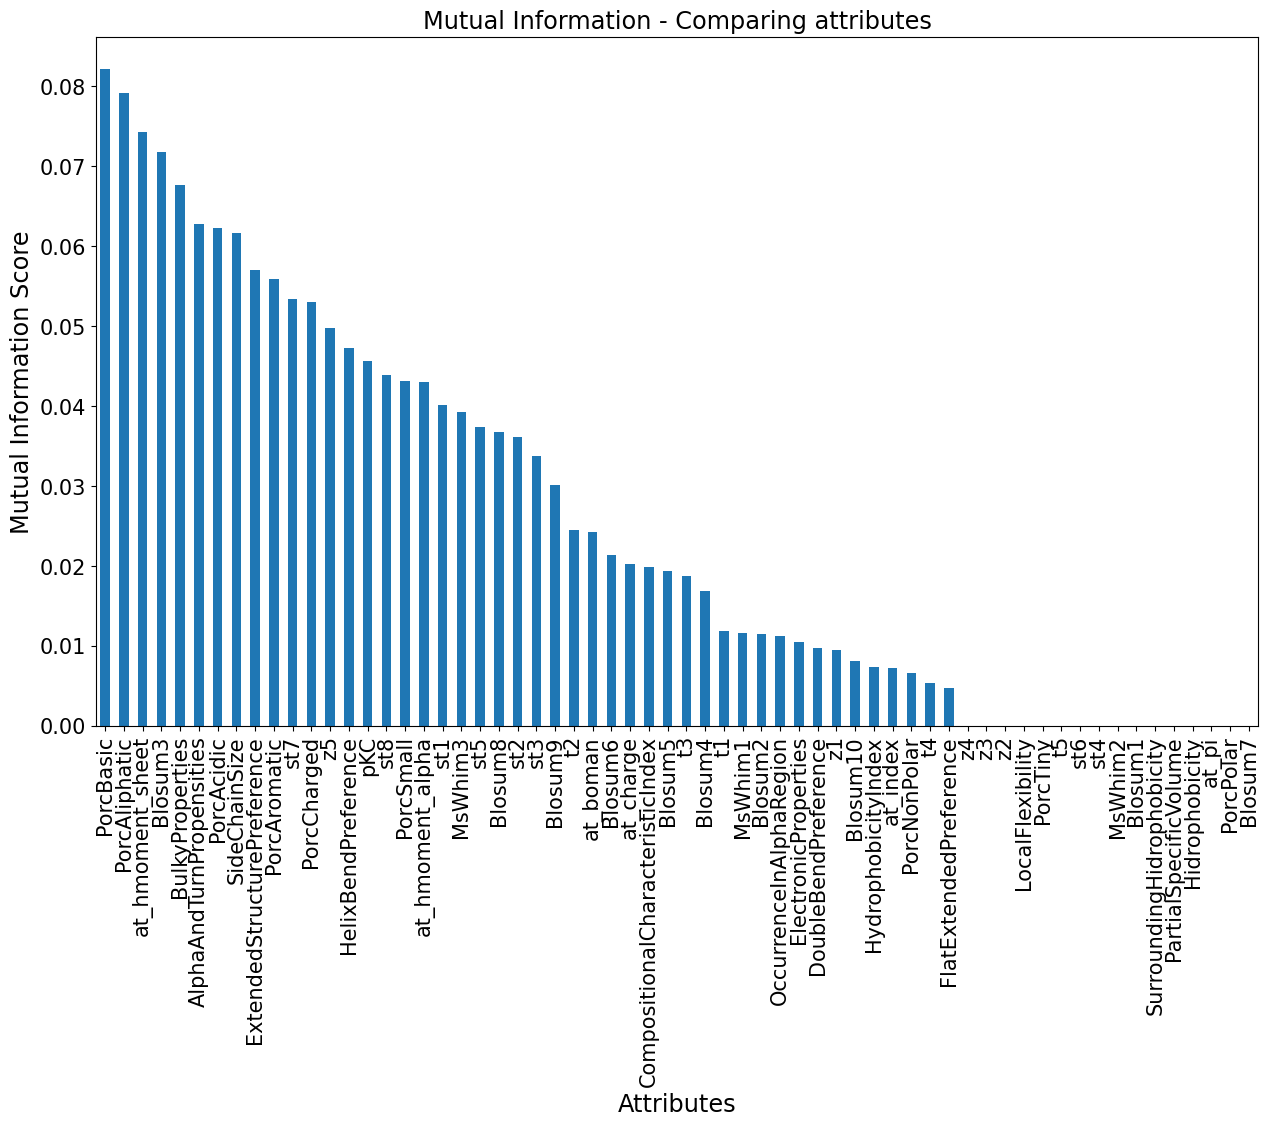

In [10]:
df2=df_ref.iloc[np.random.random_integers(152,715,152),0:74]  #SELECCION DE EJEMPLOS NEGATIVOS
df2.to_csv(f'{cdhit}-16-source_nonEpiAl_'+str(name)+'_'+str(i)+'_MI_0.csv', index=True)
df3=df_ref.iloc[0:152,0:74] #EJEMPLOS POSITIVOS
frames = [df3, df2]
df4=pd.concat(frames)
X_r=df4[feature_cols]    #SELECCION DE LOS DESCRIPTORES ELEGIDOS
Y_r=df4.Class
Y_r.value_counts()
X_rn=preprocessing.normalize(X_r)          #ESCALAR VALORES DE DESCRIPTORS
X_train,X_test,y_train,y_test=train_test_split(X_rn,Y_r,test_size=0.2,random_state=123)

mutual_info = mutual_info_classif(X_train, y_train,random_state=123)
print(mutual_info)
mutual_info = pd.Series(mutual_info)
mutual_info.index = feature_cols
mutual_info.sort_values(ascending=False).plot.bar(figsize=(15, 13))

sel = SelectKBest(mutual_info_classif, k='all')
mi=sel.fit(X_train, y_train)
mutual_info.index[sel.get_support()]
plt.subplots_adjust(bottom=0.35)
plt.xticks(fontsize='15')
plt.yticks(fontsize='15')

plt.title("Mutual Information - Comparing attributes",fontsize='xx-large')
plt.xlabel("Attributes",fontsize='xx-large')
plt.ylabel("Mutual Information Score",fontsize='xx-large')
plt.savefig(f'{cdhit}-16-MutualInfo_NegEpiAl.png',pad_inches=1.5)

In [11]:
graph_acc=[]
V_range = range(0, 62)
W_range = range(0, 100)
Acc = []
Rec = []
Pre = []
Std = []
Mean = []
fc = []
feature_col = mutual_info.sort_values(ascending=False).index[sel.get_support()]
print(feature_col)
for k in V_range: #veces de atributo
    fc.append(feature_col[k])
    print(df_ref[fc].head(0))
    for l in W_range:
        df2=df_ref.iloc[np.random.random_integers(152,715,152),0:74] #0:62
        df3=df_ref.iloc[0:152,0:74] #0:62
        frames = [df3, df2]
        df4=pd.concat(frames)
        X_r=df4[fc]
        Y_r=df4.Class
        Y_r.value_counts()
        X_rn=preprocessing.normalize(X_r)
        X_train, X_test, y_train, y_test = train_test_split(X_rn,Y_r, test_size=0.20,random_state=123)
        RF=RandomForestClassifier(random_state=123)#,n_estimators=1000)
        RF.fit(X_train,y_train)
        y_pred = RF.predict(X_test)
        Acc.append(metrics.accuracy_score(y_test, y_pred))
        Rec.append(metrics.recall_score(y_test,y_pred,average='binary',pos_label = 1))
        Pre.append(metrics.precision_score(y_test,y_pred,average='binary',pos_label = 1))
    #print(np.mean(Acc))
    Mean.append(np.mean(Acc))
    Std.append(np.std(Acc))



Index(['PorcBasic', 'PorcAliphatic', 'at_hmoment_sheet', 'Blosum3',
       'BulkyProperties', 'AlphaAndTurnPropensities', 'PorcAcidic',
       'SideChainSize', 'ExtendedStructurePreference', 'PorcAromatic', 'st7',
       'PorcCharged', 'z5', 'HelixBendPreference', 'pKC', 'st8', 'PorcSmall',
       'at_hmoment_alpha', 'st1', 'MsWhim3', 'st5', 'Blosum8', 'st2', 'st3',
       'Blosum9', 't2', 'at_boman', 'Blosum6', 'at_charge',
       'CompositionalCharacteristicIndex', 'Blosum5', 't3', 'Blosum4', 't1',
       'MsWhim1', 'Blosum2', 'OccurrenceInAlphaRegion', 'ElectronicProperties',
       'DoubleBendPreference', 'z1', 'Blosum10', 'HydrophobicityIndex',
       'at_index', 'PorcNonPolar', 't4', 'FlatExtendedPreference', 'z4', 'z3',
       'z2', 'LocalFlexibility', 'PorcTiny', 't5', 'st6', 'st4', 'MsWhim2',
       'Blosum1', 'SurroundingHidrophobicity', 'PartialSpecificVolume',
       'Hidrophobicity', 'at_pi', 'PorcPolar', 'Blosum7'],
      dtype='object')
Empty DataFrame
Columns: [PorcBasi

In [12]:
print(*mutual_info.sort_values(ascending=False).index[sel.get_support()][0:20],sep = ", ")
print(*mutual_info.sort_values(ascending=False))

PorcBasic, PorcAliphatic, at_hmoment_sheet, Blosum3, BulkyProperties, AlphaAndTurnPropensities, PorcAcidic, SideChainSize, ExtendedStructurePreference, PorcAromatic, st7, PorcCharged, z5, HelixBendPreference, pKC, st8, PorcSmall, at_hmoment_alpha, st1, MsWhim3
0.08212335509861957 0.0791119610946982 0.07432983596035769 0.07184305384633505 0.06760429991622274 0.06278487951038292 0.06230293018130184 0.06164381093104265 0.05706147457673838 0.05591093134549108 0.05341681147979527 0.0529889474105294 0.04973555860884704 0.04721918091999333 0.04560378100212392 0.04388369677477755 0.04314897700411002 0.043056235841442136 0.04014770914932786 0.03925527125855255 0.037424886884595 0.03679756664035394 0.036081124874529635 0.03372829937355615 0.030096505926947792 0.024488396615134578 0.024174421609801655 0.021334246238762233 0.02026996986584373 0.019791184819157426 0.019321842238340547 0.018673605440293395 0.016868008920309707 0.01185932472680351 0.011531861300211554 0.011475192398226808 0.011269653

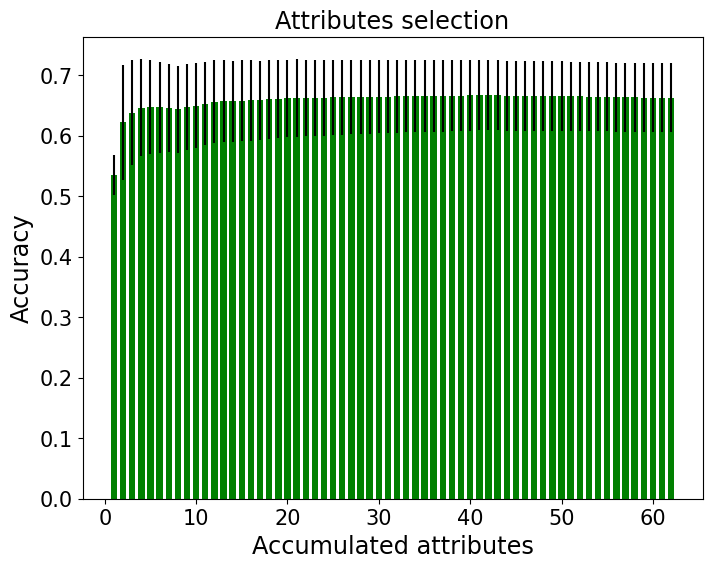

In [13]:
#plot
rango=[]
#print(graph_acc)
for i in V_range:
    rango.append(i+1)
    
import matplotlib.pyplot as plot
plt.figure(figsize=(8,6))
plt.bar(rango,Mean,yerr=Std,color="green",width=0.7)
plt.ylabel('Accuracy',fontsize='xx-large')
plt.xlabel('Accumulated attributes',fontsize='xx-large')
plt.xticks(fontsize='15')
plt.yticks(fontsize='15')
plt.title('Attributes selection',fontsize='xx-large')
plt.savefig(f'{cdhit}-16-AccuracyMutualInfo_NegEpiAl.png')
plt.show()

RF,GaussianNB,DT,XGB,SVC
acc
[0.6757377049180329, 0.6204918032786885, 0.5963934426229509, 0.5967213114754099, 0.5322950819672131] [0.0636428829853708, 0.05334170296237359, 0.06013422235018857, 0.060943050148987224, 0.06640679889943403]
rec
[0.6248275862068965, 0.6434482758620689, 0.5955172413793103, 0.6672413793103449, 0.6272413793103447] [0.08492565119372217, 0.05073068946649102, 0.17336667717944693, 0.10809946096149817, 0.1153699524205588]
pre
[0.674374151856674, 0.5973599530659031, 0.5825815657035307, 0.5699968541074665, 0.5078112787452106] [0.07798275701496026, 0.059806810838987, 0.0773957921026119, 0.06562900611496798, 0.06365366831369704]
f1
[0.6459476635003906, 0.6178011378022427, 0.5731092998843952, 0.6089725801406353, 0.5577149908146187] [0.07124402484850327, 0.04448962881321935, 0.09362460628720641, 0.0633741070793078, 0.07270935100645003]
matt
[0.3509419909425885, 0.244315557158766, 0.20259512464511997, 0.20517412473842078, 0.07539481915430116] [0.1283405889280573, 0.1045262

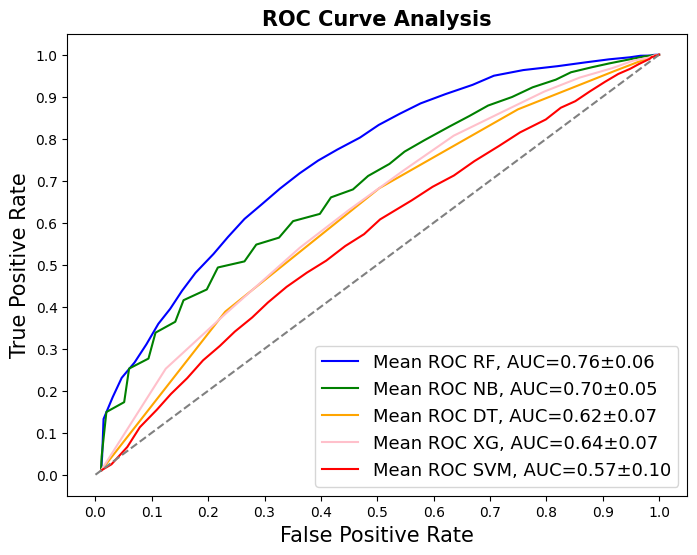

In [16]:
#mutualinfo
classifiers = [RandomForestClassifier(random_state=123),
               GaussianNB(var_smoothing=1e-9),
               DecisionTreeClassifier(random_state=123,min_samples_split=100),
               xgb.XGBClassifier(n_estimators=2, max_depth=2, learning_rate=1, objective='binary:logistic'),
               SVC(random_state=123, probability=True)]  
#("RF,GaussianNB,DT,XGB,SVM")       

#TABLA RESULTADOS SOBRE MATRIZ DE CONFUSION Y CURVA ROC
result_table = pd.DataFrame(columns=['classifiers','fpr','tpr','auc'])

graph_acc=[]
Acc = [];Rec = [];Pre = [];acc = [];rec = [];pre = [];acc_std = [];rec_std = [];pre_std = [];F1 = [];Matt = [];f1 = []; matt=[];f1_std = []; matt_std = []
Std = [];Mean = [];Fpr = [];Tpr = [];Auc = [];Auc2 = [];Auc3 = []
mean_tpr=[]; W_range = range(0, 100)

#ANOVA 
fc2=mutual_info.sort_values(ascending=False).index[sel.get_support()][0:20]


count = 0

for cls in classifiers: #BUCLE PARA CADA ALGORITMO CLASIFICADOR, RANDOM FOREST
    count=count+1
    if count == 1:
        name = "RF"
    if count == 2:
        name = "NB"
    if count == 3:
        name = "DT"
    if count == 4:
        name = "SVM"
    if count ==5:
        name = "XG"

    #print(cls)
    for i in W_range:   #BUCLE DE 100 REPETICIONES
        fpr_all=[]      #SETEAR VARIABLES, LISTAS VACÍAS PARA MATRIZ DE COSTO
        tpr_all=[]
        df2=df_ref.iloc[np.random.random_integers(152,715,152),0:74]  #SELECCION DE EJEMPLOS NEGATIVOS
        df2.to_csv(f'{cdhit}-16-source_nonEpAl_'+str(name)+'_'+str(i)+'_MI_1.csv', index=True)
        df3=df_ref.iloc[0:152,0:74] #EJEMPLOS POSITIVOS
        frames = [df3, df2]
        df4=pd.concat(frames)
        X_r=df4[fc2]    #SELECCION DE LOS DESCRIPTORES ELEGIDOS
        Y_r=df4.Class
        Y_r.value_counts()
        X_rn=preprocessing.normalize(X_r)          #ESCALAR VALORES DE DESCRIPTORS
        X_train, X_test, y_train, y_test = train_test_split(X_rn,Y_r, test_size=0.20, random_state=123) #DIVIDIR SET DE DATOS EN ENTRENAMIENTO Y PRUEBA
        model = cls.fit(X_train, y_train)          #CONSTRUIR MODELO
        y_pred = model.predict_proba(X_test)[::,1] #PREDECIR VALORES PARA EL TEST
        fpr, tpr, _ = roc_curve(y_test,y_pred)     #IDENTIFICAR FALSOS Y VERDADEROS POSITIVOS PARA CONTRUIR CURVA ROC
        fpr_all.append(fpr)
        tpr_all.append(tpr)
        auc = roc_auc_score(y_test, y_pred)        #CALCULAR VALORES PARA CURVA ROC
        Auc.append(auc)
        Acc.append(metrics.accuracy_score(y_test, y_pred.round())) #CALCULAR ESTADICTICAS ACCURACY, RECALL Y PRECISION
        Rec.append(metrics.recall_score(y_test,y_pred.round(),average='binary',pos_label = 1))
        Pre.append(metrics.precision_score(y_test,y_pred.round(),average='binary',pos_label = 1))
        F1.append(metrics.f1_score(y_test,y_pred.round(),average='binary',pos_label = 1))
        Matt.append(metrics.matthews_corrcoef(y_test,y_pred.round()))
        result_table = result_table._append({'classifiers':cls.__class__.__name__,
                                        'fpr':fpr,
                                        'tpr':tpr,
                                        'auc':auc}, ignore_index=True)

    Auc2.append(np.mean(Auc))
    Auc3.append(np.std(Auc))
    acc.append(np.mean(Acc)) #RESCATAR VALORES PARA CADA CLASIFICADOR
    rec.append(np.mean(Rec))
    pre.append(np.mean(Pre))
    f1.append(np.mean(F1))
    matt.append(np.mean(Matt))
    acc_std.append(np.std(Acc))
    rec_std.append(np.std(Rec))
    pre_std.append(np.std(Pre))
    f1_std.append(np.std(F1))
    matt_std.append(np.std(Matt))
    Auc=[] #VACIAR LISTAS
    Acc=[]
    Rec=[]
    Pre=[]
    F1=[]
    Matt=[]

##IMPRESION DE ESTADISTICAS ACCURACY, RECALL Y PRECISION JUNTO A SUS DESVIACIONES
print("RF,GaussianNB,DT,XGB,SVC")
##RF,GaussianNB,DT,XGB,SVC  
print("acc")
print(acc,acc_std)
print("rec")
print(rec,rec_std)
print("pre")
print(pre,pre_std)
print("f1")
print(f1,f1_std)
print("matt")
print(matt,matt_std)

fpr_rf=result_table['fpr'][0:99]
fpr_nb=result_table['fpr'][100:199]
fpr_dt=result_table['fpr'][200:299]
fpr_xg=result_table['fpr'][300:399]
fpr_svm=result_table['fpr'][400:499]

tpr_rf=result_table['tpr'][0:99]
tpr_nb=result_table['tpr'][100:199]
tpr_dt=result_table['tpr'][200:299]
tpr_xg=result_table['tpr'][300:399]
tpr_svm=result_table['tpr'][400:499]

fpr_rf =fpr_rf.to_list()
fpr_nb =fpr_nb.to_list()
fpr_dt =fpr_dt.to_list()
fpr_xg =fpr_xg.to_list()
fpr_svm =fpr_svm.to_list()

tpr_rf =tpr_rf.to_list()
tpr_nb =tpr_nb.to_list()
tpr_dt =tpr_dt.to_list()
tpr_xg =tpr_xg.to_list()
tpr_svm=tpr_svm.to_list()

matrix=np.zeros((2000,100))
for i in np.arange(0,2000,1):
    for j in np.arange(0,100,1):
        matrix[i][j]=1
        j=j+1
    i=i+1    
fila=0
for elemento in fpr_rf:            # lista de largo 100 y de 83 valores c/u, hay que sumar las 100 filas de 83 cols 
    col=0
    for elemento2 in elemento:    # 84
        if col < 2000: #columnas
            matrix[col][fila]=elemento2
        col=col+1     # hasta el 83 #   nuevalista.append(elemento2) #  print(nuevalista)
    fila=fila+1 
mean_fpr_rf = np.mean(matrix,axis=1)
std_fpr_rf = np.std(matrix,axis=1)
for i in np.arange(0,2000,1):
    for j in np.arange(0,100,1):
        matrix[i][j]=1
        j=j+1
    i=i+1    
fila=0
for elemento in tpr_rf:            # lista de largo 100 y de 83 valores c/u, hay que sumar las 100 filas de 83 cols 
    col=0
    for elemento2 in elemento:    # 84
        if col < 2000: #columnas
            matrix[col][fila]=elemento2
        col=col+1     # hasta el 83 #   nuevalista.append(elemento2) #  print(nuevalista)
    fila=fila+1 
mean_tpr_rf = np.mean(matrix,axis=1)
std_tpr_rf = np.std(matrix,axis=1)


for i in np.arange(0,2000,1):
    for j in np.arange(0,100,1):
        matrix[i][j]=1
        j=j+1
    i=i+1    
fila=0
for elemento in fpr_dt:            # lista de largo 100 y de 83 valores c/u, hay que sumar las 100 filas de 83 cols 
    col=0
    for elemento2 in elemento:    # 84
        if col < 2000: #columnas
            matrix[col][fila]=elemento2
        col=col+1     # hasta el 83 #   nuevalista.append(elemento2) #  print(nuevalista)
    fila=fila+1 
mean_fpr_dt = np.mean(matrix,axis=1)
std_fpr_dt = np.std(matrix,axis=1)

for i in np.arange(0,2000,1):
    for j in np.arange(0,100,1):
        matrix[i][j]=1
        j=j+1
    i=i+1    
fila=0
for elemento in tpr_dt:            # lista de largo 100 y de 83 valores c/u, hay que sumar las 100 filas de 83 cols 
    col=0
    for elemento2 in elemento:    # 84
        if col < 2000: #columnas
            matrix[col][fila]=elemento2
        col=col+1     # hasta el 83 #   nuevalista.append(elemento2) #  print(nuevalista)
    fila=fila+1 
mean_tpr_dt = np.mean(matrix,axis=1)
std_tpr_dt = np.std(matrix,axis=1)

matrix=np.zeros((2000,100))
for i in np.arange(0,2000,1):
    for j in np.arange(0,100,1):
        matrix[i][j]=1
        j=j+1
    i=i+1    
fila=0
for elemento in fpr_svm:            # lista de largo 100 y de 83 valores c/u, hay que sumar las 100 filas de 83 cols 
    col=0
    for elemento2 in elemento:    # 84
        if col < 2000: #columnas
            matrix[col][fila]=elemento2
        col=col+1     # hasta el 83 #   nuevalista.append(elemento2) #  print(nuevalista)
    fila=fila+1 
mean_fpr_svm = np.mean(matrix,axis=1)
std_fpr_svm = np.std(matrix,axis=1)

for i in np.arange(0,2000,1):
    for j in np.arange(0,100,1):
        matrix[i][j]=1
        j=j+1
    i=i+1    
fila=0
for elemento in tpr_svm:            # lista de largo 100 y de 83 valores c/u, hay que sumar las 100 filas de 83 cols 
    col=0
    for elemento2 in elemento:    # 84
        if col < 2000: #columnas
            matrix[col][fila]=elemento2
        col=col+1     # hasta el 83 #   nuevalista.append(elemento2) #  print(nuevalista)
    fila=fila+1 
mean_tpr_svm = np.mean(matrix,axis=1)
std_tpr_svm = np.std(matrix,axis=1)


for i in np.arange(0,2000,1):
    for j in np.arange(0,100,1):
        matrix[i][j]=1
        j=j+1
    i=i+1    
fila=0
for elemento in fpr_nb:            # lista de largo 100 y de 83 valores c/u, hay que sumar las 100 filas de 83 cols 
    col=0
    for elemento2 in elemento:    # 84
        if col < 2000: #columnas
            matrix[col][fila]=elemento2
        col=col+1     # hasta el 83 #   nuevalista.append(elemento2) #  print(nuevalista)
    fila=fila+1 
mean_fpr_nb = np.mean(matrix,axis=1)
std_fpr_nb = np.std(matrix,axis=1)

for i in np.arange(0,2000,1):
    for j in np.arange(0,100,1):
        matrix[i][j]=1
        j=j+1
    i=i+1    
fila=0
for elemento in tpr_nb:            
    col=0
    for elemento2 in elemento:    
        if col < 2000: #columnas
            matrix[col][fila]=elemento2
        col=col+1    
    fila=fila+1 
mean_tpr_nb = np.mean(matrix,axis=1)
std_tpr_nb = np.std(matrix,axis=1)
##xg
for i in np.arange(0,2000,1):
    for j in np.arange(0,100,1):
        matrix[i][j]=1
        j=j+1
    i=i+1    
fila=0
for elemento in fpr_xg:            # lista de largo 100 y de 83 valores c/u, hay que sumar las 100 filas de 83 cols 
    col=0
    for elemento2 in elemento:    # 84
        if col < 2000: #columnas
            matrix[col][fila]=elemento2
        col=col+1     # hasta el 83 #   nuevalista.append(elemento2) #  print(nuevalista)
    fila=fila+1 
mean_fpr_xg = np.mean(matrix,axis=1)
std_fpr_xg = np.std(matrix,axis=1)

for i in np.arange(0,2000,1):
    for j in np.arange(0,100,1):
        matrix[i][j]=1
        j=j+1
    i=i+1    
fila=0
for elemento in tpr_xg:            # lista de largo 100 y de 83 valores c/u, hay que sumar las 100 filas de 83 cols 
    col=0
    for elemento2 in elemento:    # 84
        if col < 2000: #columnas
            matrix[col][fila]=elemento2
        col=col+1     # hasta el 83 #   nuevalista.append(elemento2) #  print(nuevalista)
    fila=fila+1
mean_tpr_xg = np.mean(matrix,axis=1)
std_tpr_xg = np.std(matrix,axis=1)


plt.figure(figsize=(8,6))
clasif = ["RF","NB","DT","XG","SVM"]
#RF,GaussianNB,DT,XGB,SVC  
plt.plot(mean_fpr_rf, mean_tpr_rf, color='blue', label="Mean ROC {}, AUC={:.2f}±{:.2f}".format(clasif[0], Auc2[0],Auc3[0]))
plt.plot(mean_fpr_nb, mean_tpr_nb, color='green', label="Mean ROC {}, AUC={:.2f}±{:.2f}".format(clasif[1], Auc2[1],Auc3[1])) #gNB
plt.plot(mean_fpr_dt, mean_tpr_dt, color='orange', label="Mean ROC {}, AUC={:.2f}±{:.2f}".format(clasif[2], Auc2[2],Auc3[2])) #dt
plt.plot(mean_fpr_xg, mean_tpr_xg, color='pink', label="Mean ROC {}, AUC={:.2f}±{:.2f}".format(clasif[3], Auc2[3],Auc3[3])) #svc
plt.plot(mean_fpr_svm, mean_tpr_svm, color='red', label="Mean ROC {}, AUC={:.2f}±{:.2f}".format(clasif[4], Auc2[4],Auc3[4]))
plt.plot([0,1], [0,1], color='grey', linestyle='--')
plt.xticks(np.arange(0.0, 1.1, step=0.1))
plt.xlabel("False Positive Rate", fontsize=15)
plt.yticks(np.arange(0.0, 1.1, step=0.1))
plt.ylabel("True Positive Rate", fontsize=15)
plt.title('ROC Curve Analysis', fontweight='bold', fontsize=15)
plt.legend(prop={'size':13}, loc='lower right')
result_table.set_index('classifiers', inplace=True)
plt.savefig(f'{cdhit}-16-ROCcurve_2_mi_Paper.png')
plt.show()

In [17]:
##merge
fc_merge=['at_hmoment_alpha', 'at_hmoment_sheet', 'z3', 'CompositionalCharacteristicIndex', 'z5', 'PorcAliphatic', 'Blosum7', 'st4', 'PartialSpecificVolume', 'Blosum10', 'FlatExtendedPreference', 'SurroundingHidrophobicity', 'st7', 'PorcAcidic', 'at_pi', 'Blosum6', 'st6', 't3', 'at_index', 'ExtendedStructurePreference','PorcBasic', 'Blosum3','BulkyProperties', 'AlphaAndTurnPropensities', 'SideChainSize', 'PorcAromatic','PorcCharged', 'HelixBendPreference', 'pKC', 'st8', 'PorcSmall', 'st1', 'MsWhim3']
print(fc_merge)

['at_hmoment_alpha', 'at_hmoment_sheet', 'z3', 'CompositionalCharacteristicIndex', 'z5', 'PorcAliphatic', 'Blosum7', 'st4', 'PartialSpecificVolume', 'Blosum10', 'FlatExtendedPreference', 'SurroundingHidrophobicity', 'st7', 'PorcAcidic', 'at_pi', 'Blosum6', 'st6', 't3', 'at_index', 'ExtendedStructurePreference', 'PorcBasic', 'Blosum3', 'BulkyProperties', 'AlphaAndTurnPropensities', 'SideChainSize', 'PorcAromatic', 'PorcCharged', 'HelixBendPreference', 'pKC', 'st8', 'PorcSmall', 'st1', 'MsWhim3']


     at_hmoment_alpha  at_hmoment_sheet        z3  \
0            0.139191          0.211112 -0.233636   
1            0.637982          0.177533 -1.118182   
2            0.249373          0.377028 -0.482727   
3            0.553825          0.371942 -0.878462   
4            0.196790          0.267704 -0.035000   
..                ...               ...       ...   
711          0.220755          0.263968  0.428125   
712          0.220755          0.411576  0.664375   
713          0.257477          0.411576  0.813750   
714          0.259598          0.298599  0.668125   
715          0.293818          0.303253  0.300000   

     CompositionalCharacteristicIndex        z5  PorcAliphatic       Blosum7  \
0                            0.318000 -0.209091          9.091  1.554545e-01   
1                            0.384182  0.040909         45.455  5.454545e-03   
2                            0.447727  0.091818         27.273  2.050128e-18   
3                            0.089385  0.15

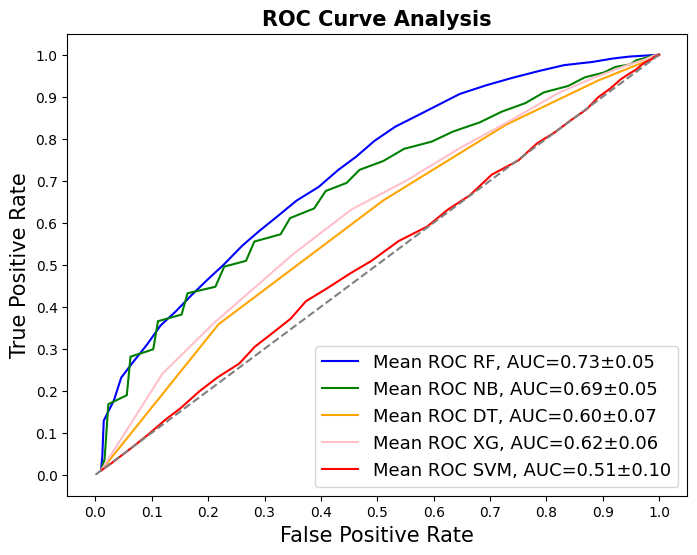

In [18]:
#TABLA RESULTADOS SOBRE MATRIZ DE CONFUSION Y CURVA ROC
result_table = pd.DataFrame(columns=['classifiers','fpr','tpr','auc'])

graph_acc=[]
Acc = [];Rec = [];Pre = [];acc = [];rec = [];pre = [];acc_std = [];rec_std = [];pre_std = [];F1 = [];Matt = [];f1 = []; matt=[];f1_std = []; matt_std = []
Std = [];Mean = [];Fpr = [];Tpr = [];Auc = [];Auc2 = [];Auc3 = []
mean_tpr=[]; W_range = range(0, 100)

X=df_ref[fc_merge]
print(X)
Y=df_ref.Class
X_p=preprocessing.normalize(X)
X_prandom=preprocessing.normalize(Xrandom)

for cls in classifiers: #BUCLE PARA CADA ALGORITMO CLASIFICADOR, RANDOM FOREST
    count=count+1
    if count == 1:
        name = "RF"
    if count == 2:
        name = "NB"
    if count == 3:
        name = "DT"
    if count == 4:
        name = "SVM"
    if count ==5:
        name = "XG"
    for i in W_range:   #BUCLE DE 100 REPETICIONES
        fpr_all=[]      #SETEAR VARIABLES, LISTAS VACÍAS PARA MATRIZ DE COSTO
        tpr_all=[]
        df2=df_ref.iloc[np.random.random_integers(152,715,152),0:74]  #SELECCION DE EJEMPLOS NEGATIVOS
        df2.to_csv(f'{cdhit}-16-source_nonEpiAl_'+str(name)+'_'+str(i)+'_merge.csv', index=True)
        df3=df_ref.iloc[0:152,0:74] #EJEMPLOS POSITIVOS
        frames = [df3, df2]
        df4=pd.concat(frames)
        X_r=df4[fc_merge]    #SELECCION DE LOS DESCRIPTORES ELEGIDOS
        Y_r=df4.Class
        Y_r.value_counts()
        X_rn=preprocessing.normalize(X_r)          #ESCALAR VALORES DE DESCRIPTORS
        X_train, X_test, y_train, y_test = train_test_split(X_rn,Y_r, test_size=0.20,random_state=123) #DIVIDIR SET DE DATOS EN ENTRENAMIENTO Y PRUEBA
        model = cls.fit(X_train, y_train)          #CONSTRUIR MODELO
        y_pred = model.predict_proba(X_test)[::,1] #PREDECIR VALORES PARA EL TEST
        fpr, tpr, _ = roc_curve(y_test,y_pred)     #IDENTIFICAR FALSOS Y VERDADEROS POSITIVOS PARA CONTRUIR CURVA ROC
        fpr_all.append(fpr)
        tpr_all.append(tpr)
        auc = roc_auc_score(y_test, y_pred)        #CALCULAR VALORES PARA CURVA ROC
        Auc.append(auc)
        Acc.append(metrics.accuracy_score(y_test, y_pred.round())) #CALCULAR ESTADICTICAS ACCURACY, RECALL Y PRECISION
        Rec.append(metrics.recall_score(y_test,y_pred.round(),average='binary',pos_label = 1))
        Pre.append(metrics.precision_score(y_test,y_pred.round(),average='binary',pos_label = 1))
        F1.append(metrics.f1_score(y_test,y_pred.round(),average='binary',pos_label = 1))
        Matt.append(metrics.matthews_corrcoef(y_test,y_pred.round()))
        result_table = result_table._append({'classifiers':cls.__class__.__name__,
                                        'fpr':fpr,
                                        'tpr':tpr,
                                        'auc':auc}, ignore_index=True)

    Auc2.append(np.mean(Auc))
    Auc3.append(np.std(Auc))
    acc.append(np.mean(Acc)) #RESCATAR VALORES PARA CADA CLASIFICADOR
    rec.append(np.mean(Rec))
    pre.append(np.mean(Pre))
    f1.append(np.mean(F1))
    matt.append(np.mean(Matt))
    acc_std.append(np.std(Acc))
    rec_std.append(np.std(Rec))
    pre_std.append(np.std(Pre))
    f1_std.append(np.std(F1))
    matt_std.append(np.std(Matt))
    Auc=[] #VACIAR LISTAS
    Acc=[]
    Rec=[]
    Pre=[]
    F1=[]
    Matt=[]

##IMPRESION DE ESTADISTICAS ACCURACY, RECALL Y PRECISION JUNTO A SUS DESVIACIONES
print("RF,GaussianNB,DT,XGB,SVC")
#RF,GaussianNB,DT,XGB,SVC 
print("acc")
print(acc,acc_std)
print("rec")
print(rec,rec_std)
print("pre")
print(pre,pre_std)
print("f1")
print(f1,f1_std)
print("matt")
print(matt,matt_std)

fpr_rf=result_table['fpr'][0:99]
fpr_nb=result_table['fpr'][100:199]
fpr_dt=result_table['fpr'][200:299]
fpr_xg=result_table['fpr'][300:399]
fpr_svm=result_table['fpr'][400:499]

tpr_rf=result_table['tpr'][0:99]
tpr_nb=result_table['tpr'][100:199]
tpr_dt=result_table['tpr'][200:299]
tpr_xg=result_table['tpr'][300:399]
tpr_svm=result_table['tpr'][400:499]

fpr_rf =fpr_rf.to_list()
fpr_nb =fpr_nb.to_list()
fpr_dt =fpr_dt.to_list()
fpr_xg =fpr_xg.to_list()
fpr_svm =fpr_svm.to_list()

tpr_rf =tpr_rf.to_list()
tpr_nb =tpr_nb.to_list()
tpr_dt =tpr_dt.to_list()
tpr_xg =tpr_xg.to_list()
tpr_svm=tpr_svm.to_list()

matrix=np.zeros((2000,100))
for i in np.arange(0,2000,1):
    for j in np.arange(0,100,1):
        matrix[i][j]=1
        j=j+1
    i=i+1    
fila=0
for elemento in fpr_rf:            # lista de largo 100 y de 83 valores c/u, hay que sumar las 100 filas de 83 cols 
    col=0
    for elemento2 in elemento:    # 84
        if col < 2000: #columnas
            matrix[col][fila]=elemento2
        col=col+1     # hasta el 83 #   nuevalista.append(elemento2) #  print(nuevalista)
    fila=fila+1 
mean_fpr_rf = np.mean(matrix,axis=1)
std_fpr_rf = np.std(matrix,axis=1)
for i in np.arange(0,2000,1):
    for j in np.arange(0,100,1):
        matrix[i][j]=1
        j=j+1
    i=i+1    
fila=0
for elemento in tpr_rf:            # lista de largo 100 y de 83 valores c/u, hay que sumar las 100 filas de 83 cols 
    col=0
    for elemento2 in elemento:    # 84
        if col < 2000: #columnas
            matrix[col][fila]=elemento2
        col=col+1     # hasta el 83 #   nuevalista.append(elemento2) #  print(nuevalista)
    fila=fila+1 
mean_tpr_rf = np.mean(matrix,axis=1)
std_tpr_rf = np.std(matrix,axis=1)


for i in np.arange(0,2000,1):
    for j in np.arange(0,100,1):
        matrix[i][j]=1
        j=j+1
    i=i+1    
fila=0
for elemento in fpr_dt:            # lista de largo 100 y de 83 valores c/u, hay que sumar las 100 filas de 83 cols 
    col=0
    for elemento2 in elemento:    # 84
        if col < 2000: #columnas
            matrix[col][fila]=elemento2
        col=col+1     # hasta el 83 #   nuevalista.append(elemento2) #  print(nuevalista)
    fila=fila+1 
mean_fpr_dt = np.mean(matrix,axis=1)
std_fpr_dt = np.std(matrix,axis=1)

for i in np.arange(0,2000,1):
    for j in np.arange(0,100,1):
        matrix[i][j]=1
        j=j+1
    i=i+1    
fila=0
for elemento in tpr_dt:            # lista de largo 100 y de 83 valores c/u, hay que sumar las 100 filas de 83 cols 
    col=0
    for elemento2 in elemento:    # 84
        if col < 2000: #columnas
            matrix[col][fila]=elemento2
        col=col+1     # hasta el 83 #   nuevalista.append(elemento2) #  print(nuevalista)
    fila=fila+1 
mean_tpr_dt = np.mean(matrix,axis=1)
std_tpr_dt = np.std(matrix,axis=1)

matrix=np.zeros((2000,100))
for i in np.arange(0,2000,1):
    for j in np.arange(0,100,1):
        matrix[i][j]=1
        j=j+1
    i=i+1    
fila=0
for elemento in fpr_svm:            # lista de largo 100 y de 83 valores c/u, hay que sumar las 100 filas de 83 cols 
    col=0
    for elemento2 in elemento:    # 84
        if col < 2000: #columnas
            matrix[col][fila]=elemento2
        col=col+1     # hasta el 83 #   nuevalista.append(elemento2) #  print(nuevalista)
    fila=fila+1 
mean_fpr_svm = np.mean(matrix,axis=1)
std_fpr_svm = np.std(matrix,axis=1)

for i in np.arange(0,2000,1):
    for j in np.arange(0,100,1):
        matrix[i][j]=1
        j=j+1
    i=i+1    
fila=0
for elemento in tpr_svm:            # lista de largo 100 y de 83 valores c/u, hay que sumar las 100 filas de 83 cols 
    col=0
    for elemento2 in elemento:    # 84
        if col < 2000: #columnas
            matrix[col][fila]=elemento2
        col=col+1     # hasta el 83 #   nuevalista.append(elemento2) #  print(nuevalista)
    fila=fila+1 
mean_tpr_svm = np.mean(matrix,axis=1)
std_tpr_svm = np.std(matrix,axis=1)


for i in np.arange(0,2000,1):
    for j in np.arange(0,100,1):
        matrix[i][j]=1
        j=j+1
    i=i+1    
fila=0
for elemento in fpr_nb:            # lista de largo 100 y de 83 valores c/u, hay que sumar las 100 filas de 83 cols 
    col=0
    for elemento2 in elemento:    # 84
        if col < 2000: #columnas
            matrix[col][fila]=elemento2
        col=col+1     # hasta el 83 #   nuevalista.append(elemento2) #  print(nuevalista)
    fila=fila+1 
mean_fpr_nb = np.mean(matrix,axis=1)
std_fpr_nb = np.std(matrix,axis=1)

for i in np.arange(0,2000,1):
    for j in np.arange(0,100,1):
        matrix[i][j]=1
        j=j+1
    i=i+1    
fila=0
for elemento in tpr_nb:            
    col=0
    for elemento2 in elemento:    
        if col < 2000: #columnas
            matrix[col][fila]=elemento2
        col=col+1    
    fila=fila+1 
mean_tpr_nb = np.mean(matrix,axis=1)
std_tpr_nb = np.std(matrix,axis=1)
##xg
for i in np.arange(0,2000,1):
    for j in np.arange(0,100,1):
        matrix[i][j]=1
        j=j+1
    i=i+1    
fila=0
for elemento in fpr_xg:            # lista de largo 100 y de 83 valores c/u, hay que sumar las 100 filas de 83 cols 
    col=0
    for elemento2 in elemento:    # 84
        if col < 2000: #columnas
            matrix[col][fila]=elemento2
        col=col+1     # hasta el 83 #   nuevalista.append(elemento2) #  print(nuevalista)
    fila=fila+1 
mean_fpr_xg = np.mean(matrix,axis=1)
std_fpr_xg = np.std(matrix,axis=1)

for i in np.arange(0,2000,1):
    for j in np.arange(0,100,1):
        matrix[i][j]=1
        j=j+1
    i=i+1    
fila=0
for elemento in tpr_xg:            # lista de largo 100 y de 83 valores c/u, hay que sumar las 100 filas de 83 cols 
    col=0
    for elemento2 in elemento:    # 84
        if col < 2000: #columnas
            matrix[col][fila]=elemento2
        col=col+1     # hasta el 83 #   nuevalista.append(elemento2) #  print(nuevalista)
    fila=fila+1
mean_tpr_xg = np.mean(matrix,axis=1)
std_tpr_xg = np.std(matrix,axis=1)


plt.figure(figsize=(8,6))
clasif = ["RF","NB","DT","XG","SVM"]
#RF,GaussianNB,DT,XGB,SVC 
plt.plot(mean_fpr_rf, mean_tpr_rf, color='blue', label="Mean ROC {}, AUC={:.2f}±{:.2f}".format(clasif[0], Auc2[0],Auc3[0]))
plt.plot(mean_fpr_nb, mean_tpr_nb, color='green', label="Mean ROC {}, AUC={:.2f}±{:.2f}".format(clasif[1], Auc2[1],Auc3[1]))
plt.plot(mean_fpr_dt, mean_tpr_dt, color='orange', label="Mean ROC {}, AUC={:.2f}±{:.2f}".format(clasif[2], Auc2[2],Auc3[2]))
plt.plot(mean_fpr_xg, mean_tpr_xg, color='pink', label="Mean ROC {}, AUC={:.2f}±{:.2f}".format(clasif[3], Auc2[3],Auc3[3]))
plt.plot(mean_fpr_svm, mean_tpr_svm, color='red', label="Mean ROC {}, AUC={:.2f}±{:.2f}".format(clasif[4], Auc2[4],Auc3[4]))
plt.plot([0,1], [0,1], color='grey', linestyle='--')
plt.xticks(np.arange(0.0, 1.1, step=0.1))
plt.xlabel("False Positive Rate", fontsize=15)
plt.yticks(np.arange(0.0, 1.1, step=0.1))
plt.ylabel("True Positive Rate", fontsize=15)
plt.title('ROC Curve Analysis', fontweight='bold', fontsize=15)
plt.legend(prop={'size':13}, loc='lower right')
result_table.set_index('classifiers', inplace=True)
plt.savefig(f'{cdhit}-16-ROCcurve_3_mix.png')
plt.show()


## Test the model with all the epitopes


In [19]:
##merge
fc_merge = ['at_hmoment_alpha', 'at_hmoment_sheet', 'z3', 'CompositionalCharacteristicIndex', 'z5', 'PorcAliphatic', 'Blosum7', 'st4', 'PartialSpecificVolume', 'Blosum10', 'FlatExtendedPreference', 'SurroundingHidrophobicity', 'st7', 'PorcAcidic', 'at_pi', 'Blosum6', 'st6', 't3', 'at_index', 'ExtendedStructurePreference','PorcBasic', 'Blosum3','BulkyProperties', 'AlphaAndTurnPropensities', 'SideChainSize', 'PorcAromatic','PorcCharged', 'HelixBendPreference', 'pKC', 'st8', 'PorcSmall', 'st1', 'MsWhim3']

print(fc_merge)

['at_hmoment_alpha', 'at_hmoment_sheet', 'z3', 'CompositionalCharacteristicIndex', 'z5', 'PorcAliphatic', 'Blosum7', 'st4', 'PartialSpecificVolume', 'Blosum10', 'FlatExtendedPreference', 'SurroundingHidrophobicity', 'st7', 'PorcAcidic', 'at_pi', 'Blosum6', 'st6', 't3', 'at_index', 'ExtendedStructurePreference', 'PorcBasic', 'Blosum3', 'BulkyProperties', 'AlphaAndTurnPropensities', 'SideChainSize', 'PorcAromatic', 'PorcCharged', 'HelixBendPreference', 'pKC', 'st8', 'PorcSmall', 'st1', 'MsWhim3']


acc
[0.6480327868852459] [0.05449210905203117]
rec
[0.5841379310344827] [0.06665437857421926]
pre
[0.6481864760767911] [0.07354499388307187]
f1
[0.6119292732266124] [0.05670907181714329]
matt
[0.29493524084276934] [0.11042119269877584]
balacc
[0.6450377155172414] [0.05369984632066358]
spec
[0.7059375] [0.08728712945646684]


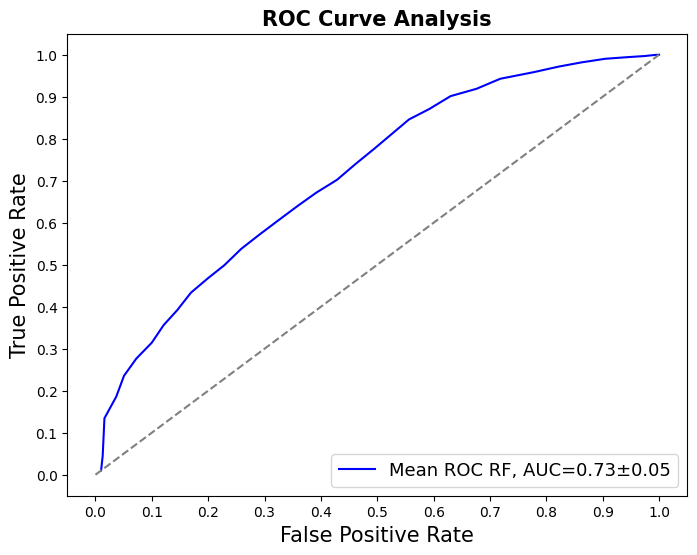

['85-16-modelAl.joblib']

In [21]:
#save model
from sklearn.ensemble import RandomForestClassifier
from joblib import dump, load
import pandas as pd
import numpy as np
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.metrics import balanced_accuracy_score

import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

#input
cols=[*range(1, 75, 1)]
df_ref = pd.read_csv(f'{cdhit}-16-descriptors_class_Algorithm.csv', sep=',',usecols=cols)
feature_cols = fc_merge
#['PorcTiny','PorcSmall','PorcAliphatic','PorcAromatic','PorcNonPolar','PorcPolar','PorcCharged','PorcBasic','PorcAcidic','at_index','at_boman','at_charge','at_pi','at_hmoment_alpha','at_hmoment_sheet','HelixBendPreference','SideChainSize','ExtendedStructurePreference','Hidrophobicity','DoubleBendPreference','PartialSpecificVolume','FlatExtendedPreference','OccurrenceInAlphaRegion','pKC','SurroundingHidrophobicity','Blosum1','Blosum2','Blosum3','Blosum4','Blosum5','Blosum6','Blosum7','Blosum8','Blosum9','Blosum10','MsWhim1','MsWhim2','MsWhim3','st1','st2','st3','st4','st5','st6','st7','st8','t1','t2','t3','t4','t5','z1','z2','z3','z4','z5','HydrophobicityIndex','AlphaAndTurnPropensities','BulkyProperties','CompositionalCharacteristicIndex','LocalFlexibility','ElectronicProperties']

#TABLA RESULTADOS SOBRE MATRIZ DE CONFUSION Y CURVA ROC
classifiers = [RandomForestClassifier(random_state=123)]
result_table = pd.DataFrame(columns=['classifiers','fpr','tpr','auc'])

graph_acc=[]
Acc = [];Rec = [];Pre = [];acc = [];rec = [];pre = [];acc_std = [];rec_std = [];pre_std = [];F1 = [];Matt = [];f1 = []; matt=[];f1_std = []; matt_std = []
Std = [];Mean = [];Fpr = [];Tpr = [];Auc = [];spec=[];Spec = [];spec_std =[];balacc=[];BalAcc=[];balacc_std=[]
mean_tpr=[]; W_range = range(0, 100)

for cls in classifiers: #BUCLE PARA CADA ALGORITMO CLASIFICADOR, RANDOM FOREST
    for i in W_range:   #BUCLE DE 100 REPETICIONES
        fpr_all=[]      #SETEAR VARIABLES, LISTAS VACÍAS PARA MATRIZ DE COSTO
        tpr_all=[]
        df2=df_ref.iloc[np.random.random_integers(152,715,152),0:74]  #SELECCION DE EJEMPLOS NEGATIVOS
        df2.to_csv(f'{cdhit}-16-source_AlModel_RF_'+str(i)+'.csv', index=True)
        df3=df_ref.iloc[0:152,0:74] #EJEMPLOS POSITIVOS
        frames = [df3, df2]
        df4=pd.concat(frames)
        X_r=df4[fc_merge]    #SELECCION DE LOS DESCRIPTORES ELEGIDOS
        Y_r=df4.Class
        Y_r.value_counts()
        X_rn=preprocessing.normalize(X_r)          #ESCALAR VALORES DE DESCRIPTORS
        X_train, X_test, y_train, y_test = train_test_split(X_rn,Y_r, test_size=0.2, random_state=123) #DIVIDIR SET DE DATOS EN ENTRENAMIENTO Y PRUEBA
        model = cls.fit(X_train, y_train)          #CONSTRUIR MODELO
        y_pred = model.predict_proba(X_test)[::,1] #PREDECIR VALORES PARA EL TEST
        fpr, tpr, _ = roc_curve(y_test,y_pred)     #IDENTIFICAR FALSOS Y VERDADEROS POSITIVOS PARA CONTRUIR CURVA ROC
        fpr_all.append(fpr)
        tpr_all.append(tpr)
        auc = roc_auc_score(y_test, y_pred)        #CALCULAR VALORES PARA CURVA ROC
        Auc.append(auc)
        Acc.append(metrics.accuracy_score(y_test, y_pred.round())) #CALCULAR ESTADICTICAS ACCURACY, RECALL Y PRECISION
        Rec.append(metrics.recall_score(y_test,y_pred.round(),average='binary',pos_label = 1))
        Pre.append(metrics.precision_score(y_test,y_pred.round(),average='binary',pos_label = 1))
        F1.append(metrics.f1_score(y_test,y_pred.round(),average='binary',pos_label = 1))
        Matt.append(metrics.matthews_corrcoef(y_test,y_pred.round()))
        Spec.append(metrics.recall_score(y_test, y_pred.round(), average='binary',pos_label = 0))
        BalAcc.append(metrics.balanced_accuracy_score(y_test, y_pred.round()))
        result_table = result_table._append({'classifiers':cls.__class__.__name__,
                                        'fpr':fpr,
                                        'tpr':tpr,
                                        'auc':auc}, ignore_index=True)

    acc.append(np.mean(Acc)) #RESCATAR VALORES PARA CADA CLASIFICADOR
    rec.append(np.mean(Rec))
    pre.append(np.mean(Pre))
    f1.append(np.mean(F1))
    balacc.append(np.mean(BalAcc))
    spec.append(np.mean(Spec))
    matt.append(np.mean(Matt))
    acc_std.append(np.std(Acc))
    rec_std.append(np.std(Rec))
    pre_std.append(np.std(Pre))
    f1_std.append(np.std(F1))
    balacc_std.append(np.std(BalAcc))
    spec_std.append(np.std(Spec))
    matt_std.append(np.std(Matt))
    Auc=[] #VACIAR LISTAS
    Acc=[]
    Rec=[]
    Pre=[]
    F1=[]
    Matt=[]
    BalAcc=[]
    Spec=[]

##IMPRESION DE ESTADISTICAS ACCURACY, RECALL Y PRECISION JUNTO A SUS DESVIACIONES

print("acc")
print(acc,acc_std)
print("rec")
print(rec,rec_std)
print("pre")
print(pre,pre_std)
print("f1")
print(f1,f1_std)
print("matt")
print(matt,matt_std)
print("balacc")
print(balacc,balacc_std)
print("spec")
print(spec,spec_std)

fpr_rf=result_table['fpr'][0:99]
tpr_rf=result_table['tpr'][0:99]
fpr_rf =fpr_rf.to_list()
tpr_rf =tpr_rf.to_list()

matrix=np.zeros((2000,100))
for i in np.arange(0,2000,1):
    for j in np.arange(0,100,1):
        matrix[i][j]=1
        j=j+1
    i=i+1    
fila=0
for elemento in fpr_rf:            # lista de largo 100 y de 83 valores c/u, hay que sumar las 100 filas de 83 cols 
    col=0
    for elemento2 in elemento:    # 84
        if col < 2000: #columnas
            matrix[col][fila]=elemento2
        col=col+1     # hasta el 83 #   nuevalista.append(elemento2) #  print(nuevalista)
    fila=fila+1 
mean_fpr_rf = np.mean(matrix,axis=1)
std_fpr_rf = np.std(matrix,axis=1)
for i in np.arange(0,2000,1):
    for j in np.arange(0,100,1):
        matrix[i][j]=1
        j=j+1
    i=i+1    
fila=0
for elemento in tpr_rf:            # lista de largo 100 y de 83 valores c/u, hay que sumar las 100 filas de 83 cols 
    col=0
    for elemento2 in elemento:    # 84
        if col < 2000: #columnas
            matrix[col][fila]=elemento2
        col=col+1     # hasta el 83 #   nuevalista.append(elemento2) #  print(nuevalista)
    fila=fila+1 
mean_tpr_rf = np.mean(matrix,axis=1)
std_tpr_rf = np.std(matrix,axis=1)

plt.figure(figsize=(8,6))
clasif = ["RF"]
plt.plot(mean_fpr_rf, mean_tpr_rf, color='blue', label="Mean ROC {}, AUC={:.2f}±{:.2f}".format(clasif[0], Auc2[0],Auc3[0]))
plt.plot([0,1], [0,1], color='grey', linestyle='--')
plt.xticks(np.arange(0.0, 1.1, step=0.1))
plt.xlabel("False Positive Rate", fontsize=15)
plt.yticks(np.arange(0.0, 1.1, step=0.1))
plt.ylabel("True Positive Rate", fontsize=15)
plt.title('ROC Curve Analysis', fontweight='bold', fontsize=15)
plt.legend(prop={'size':13}, loc='lower right')
result_table.set_index('classifiers', inplace=True)
plt.savefig(f'{cdhit}-12-save_Paper.png')
plt.show()
cls_paper=cls
dump(cls_paper, f'{cdhit}-16-modelAl.joblib') 


## Final Model using All data set

In [22]:
import numpy as np
from sklearn import metrics
from sklearn.metrics import accuracy_score 
##merge
#fc_merge=['at_hmoment_sheet', 'at_hmoment_alpha', 'Blosum9', 'ExtendedStructurePreference', 'st7', 'at_index', 'z3', 'Blosum6', 'PorcNonPolar', 'at_pi', 'st8', 'PorcPolar', 'st5', 'ElectronicProperties', 'Blosum8', 'Blosum10', 'PartialSpecificVolume', 'LocalFlexibility', 'MsWhim2', 'Blosum7','CompositionalCharacteristicIndex', 'DoubleBendPreference', 'PorcBasic', 'PorcCharged', 'PorcAliphatic', 'z2', 'SurroundingHidrophobicity', 'PorcAromatic', 'OccurrenceInAlphaRegion', 'st3', 'MsWhim1']
fc_merge = ['at_hmoment_alpha', 'at_hmoment_sheet', 'z3', 'CompositionalCharacteristicIndex', 'z5', 'PorcAliphatic', 'Blosum7', 'st4', 'PartialSpecificVolume', 'Blosum10', 'FlatExtendedPreference', 'SurroundingHidrophobicity', 'st7', 'PorcAcidic', 'at_pi', 'Blosum6', 'st6', 't3', 'at_index', 'ExtendedStructurePreference','PorcBasic', 'Blosum3','BulkyProperties', 'AlphaAndTurnPropensities', 'SideChainSize', 'PorcAromatic','PorcCharged', 'HelixBendPreference', 'pKC', 'st8', 'PorcSmall', 'st1', 'MsWhim3']

#input
cols=[*range(1, 75, 1)]
df_ref = pd.read_csv(f'{cdhit}-16-descriptors_class_Algorithm.csv', sep=',',usecols=cols)
feature_cols =['PorcTiny','PorcSmall','PorcAliphatic','PorcAromatic','PorcNonPolar','PorcPolar','PorcCharged','PorcBasic','PorcAcidic','at_index','at_boman','at_charge','at_pi','at_hmoment_alpha','at_hmoment_sheet','HelixBendPreference','SideChainSize','ExtendedStructurePreference','Hidrophobicity','DoubleBendPreference','PartialSpecificVolume','FlatExtendedPreference','OccurrenceInAlphaRegion','pKC','SurroundingHidrophobicity','Blosum1','Blosum2','Blosum3','Blosum4','Blosum5','Blosum6','Blosum7','Blosum8','Blosum9','Blosum10','MsWhim1','MsWhim2','MsWhim3','st1','st2','st3','st4','st5','st6','st7','st8','t1','t2','t3','t4','t5','z1','z2','z3','z4','z5','HydrophobicityIndex','AlphaAndTurnPropensities','BulkyProperties','CompositionalCharacteristicIndex','LocalFlexibility','ElectronicProperties']
df_ref.to_csv(f'{cdhit}-16-source_AllDataAl.csv', index=True)
X_final=df_ref[fc_merge]    #SELECCION DE LOS DESCRIPTORES ELEGIDOS
y_final=df_ref.Class

final_model = RandomForestClassifier(random_state=123)
final_model.fit(X_final, y_final)
dump(final_model, f'{cdhit}-16-modelAl.joblib') 
#y_preds = final_model.predict(X_final)
#print(list(y_preds))
#print(list(y_final))
#accuracy = accuracy_score(y_final, y_preds)
#print(f"Test Accuracy: {test_acc:.2f}")

['85-16-modelAl.joblib']

In [23]:
from sklearn.ensemble import RandomForestClassifier

fc3= ['at_hmoment_alpha', 'at_hmoment_sheet', 'z3', 'CompositionalCharacteristicIndex', 'z5', 'PorcAliphatic', 'Blosum7', 'st4', 'PartialSpecificVolume', 'Blosum10', 'FlatExtendedPreference', 'SurroundingHidrophobicity', 'st7', 'PorcAcidic', 'at_pi', 'Blosum6', 'st6', 't3', 'at_index', 'ExtendedStructurePreference','PorcBasic', 'Blosum3','BulkyProperties', 'AlphaAndTurnPropensities', 'SideChainSize', 'PorcAromatic','PorcCharged', 'HelixBendPreference', 'pKC', 'st8', 'PorcSmall', 'st1', 'MsWhim3']
X = pd.read_csv(f'{cdhit}-16-descriptors_class_Algorithm.csv', sep=',',usecols=cols)

predicciones = final_model.predict(X[fc3])

y_prueba_real = X.Class

exactitud = metrics.accuracy_score(y_prueba_real, predicciones)
#print("real")
#print(list(y_prueba_real))
#print("pred")
#print(list(predicciones))
print(f'Accurracy for influenza epitopes 100/100: {exactitud}')

Accurracy for influenza epitopes 100/100: 1.0


In [24]:
from sklearn.ensemble import RandomForestClassifier

fc3= ['at_hmoment_alpha', 'at_hmoment_sheet', 'z3', 'CompositionalCharacteristicIndex', 'z5', 'PorcAliphatic', 'Blosum7', 'st4', 'PartialSpecificVolume', 'Blosum10', 'FlatExtendedPreference', 'SurroundingHidrophobicity', 'st7', 'PorcAcidic', 'at_pi', 'Blosum6', 'st6', 't3', 'at_index', 'ExtendedStructurePreference','PorcBasic', 'Blosum3','BulkyProperties', 'AlphaAndTurnPropensities', 'SideChainSize', 'PorcAromatic','PorcCharged', 'HelixBendPreference', 'pKC', 'st8', 'PorcSmall', 'st1', 'MsWhim3']

X = pd.read_csv('descriptors_class_vaccines_hv1.csv', sep=',',usecols=cols)

predicciones = final_model.predict(X[fc3])

y_prueba_real = X.Class

exactitud = metrics.accuracy_score(y_prueba_real, predicciones)

print(f'Accurracy for herpes virus epitopes 100/100: {exactitud}')


Accurracy for herpes virus epitopes 100/100: 0.49196633511859217


In [25]:
from sklearn.ensemble import RandomForestClassifier

fc3=['at_hmoment_alpha', 'at_hmoment_sheet', 'z3', 'CompositionalCharacteristicIndex', 'z5', 'PorcAliphatic', 'Blosum7', 'st4', 'PartialSpecificVolume', 'Blosum10', 'FlatExtendedPreference', 'SurroundingHidrophobicity', 'st7', 'PorcAcidic', 'at_pi', 'Blosum6', 'st6', 't3', 'at_index', 'ExtendedStructurePreference','PorcBasic', 'Blosum3','BulkyProperties', 'AlphaAndTurnPropensities', 'SideChainSize', 'PorcAromatic','PorcCharged', 'HelixBendPreference', 'pKC', 'st8', 'PorcSmall', 'st1', 'MsWhim3']

X = pd.read_csv(f'{cdhit}-16-descriptors_class_Algorithm.csv', sep=',',usecols=cols)

predicciones = cls_paper.predict(X[fc3])

y_prueba_real = X.Class

exactitud = metrics.accuracy_score(y_prueba_real, predicciones)
#print("real")
#print(list(y_prueba_real))
#print("pred")
#print(list(predicciones))
print(f'Accurracy for influenza virus epitopes 80/20: {exactitud}')

Accurracy for influenza virus epitopes 80/20: 0.6885474860335196


In [26]:
from sklearn.ensemble import RandomForestClassifier

fc3=['at_hmoment_alpha', 'at_hmoment_sheet', 'z3', 'CompositionalCharacteristicIndex', 'z5', 'PorcAliphatic', 'Blosum7', 'st4', 'PartialSpecificVolume', 'Blosum10', 'FlatExtendedPreference', 'SurroundingHidrophobicity', 'st7', 'PorcAcidic', 'at_pi', 'Blosum6', 'st6', 't3', 'at_index', 'ExtendedStructurePreference','PorcBasic', 'Blosum3','BulkyProperties', 'AlphaAndTurnPropensities', 'SideChainSize', 'PorcAromatic','PorcCharged', 'HelixBendPreference', 'pKC', 'st8', 'PorcSmall', 'st1', 'MsWhim3']

X = pd.read_csv('descriptors_class_vaccines_hv1.csv', sep=',',usecols=cols)

predicciones = cls_paper.predict(X[fc3])

y_prueba_real = X.Class

exactitud = metrics.accuracy_score(y_prueba_real, predicciones)

print(f'Accurracy for herpes virus epitopes 80/20: {exactitud}')

Accurracy for herpes virus epitopes 80/20: 0.5325172149961744
